In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from pathlib import Path

In [3]:
from collections import defaultdict

def find_training_losses(model_name, df_summary):
    """Find training losses for a given model name in df_summary"""
    try:
        matches = df_summary[df_summary['filename'].str.contains(model_name, na=False)]
        if len(matches) > 0:
            losses = matches['train_losses'].iloc[0]
            if isinstance(losses, str):
                losses = eval(losses)
            elif isinstance(losses, (list, np.ndarray)):
                losses = list(losses)
            else:
                return None
            return losses
        else:
            for idx, row in df_summary.iterrows():
                if model_name in str(row['filename']):
                    losses = row['train_losses']
                    if isinstance(losses, str):
                        losses = eval(losses)
                    elif isinstance(losses, (list, np.ndarray)):
                        losses = list(losses)
                    else:
                        return None
                    return losses
    except:
        pass
    return None

from scipy.stats import pearsonr, chi2_contingency, ttest_ind
from sklearn.metrics import confusion_matrix
from transformers import EsmTokenizer
from scipy.stats import binom
import re

tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
vocab = tokenizer.get_vocab()
id_to_token = {v: k for k, v in vocab.items()}

def extract_model_info(model_name):
    encoding = "Unknown"
    layers = "Unknown"
    
    if "HLA" in model_name.upper():
        encoding = "HLA"
    elif "epitope" in model_name.lower():
        encoding = "Epitope"
    
    ft_match = re.search(r'FT[_-]?(\d+)', model_name)
    if ft_match:
        layers = ft_match.group(1)
    
    return encoding, layers


from scipy.stats import chi2_contingency, sem
import seaborn as sns
import glob

# Process each allele - selecting up to 5 models
allele_files = {
    'A0201': glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*A0201*.csv'),
    'B5101': glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B5101*.csv'),
    'B5701': glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B5701*.csv'),
    'C0401': glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*C0401*.csv'),
}

IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz',
                        sep=',', header=0)                    
# Sort each list
for allele in allele_files:
    allele_files[allele] = sorted(allele_files[allele])

# Process each allele and select top 5 models
allele_analysis_data = {}

for allele_name, trained_files in allele_files.items():
    models = {}
    accuracies = {}
    model_names = []
    model_info = {}

    for file in trained_files:
        if not os.path.exists(file) or os.path.getsize(file) < 10:
            continue
        
        try:
            df = pd.read_csv(file)
            required_columns = ['original_id', 'predicted_id', 'position']
            if not all(col in df.columns for col in required_columns):
                continue
            
            base = os.path.basename(file)
            name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
            name = name.replace("training_log_", "")
            
            df_filtered = df
            
            models[name] = df_filtered
            model_names.append(name)
            
            accuracy = (df_filtered['original_id'] == df_filtered['predicted_id']).mean()
            accuracies[name] = accuracy
            
            encoding, layers = extract_model_info(name)
            model_info[name] = {'encoding': encoding, 'layers': layers}
            
        except Exception as e:
            continue

    if not models:
        print(f"No valid model files found for {allele_name}!")
        continue
    
    # Find top 5 models by accuracy (with training validation if available)
    valid_models = {}
    if 'df_summary' in globals():
        for model_name, accuracy in accuracies.items():
            losses = find_training_losses(model_name, df_summary)
            if losses is not None and len(losses) >= 10:
                valid_models[model_name] = accuracy
    
    if not valid_models:
        valid_models = accuracies
    
    # Select top 5 models
    sorted_models = sorted(valid_models.items(), key=lambda x: x[1], reverse=True)
    top_5_models = [model_name for model_name, _ in sorted_models[:3]]
    best_model = top_5_models[0]
    
    # Calculate position-wise accuracy AND standard error for all models
    position_accuracy_all = {}
    position_stderr_all = {}
    
    for model_name in top_5_models:
        df_model = models[model_name]
        
        # Calculate accuracy
        pos_acc = df_model.groupby('position').apply(
            lambda x: (x['original_id'] == x['predicted_id']).mean()
        )
        position_accuracy_all[model_name] = pos_acc
        
        # Calculate standard error
        pos_stderr = df_model.groupby('position').apply(
            lambda x: sem((x['original_id'] == x['predicted_id']).astype(int))
        )
        position_stderr_all[model_name] = pos_stderr
    
    # Calculate per-residue perplexity for best model only
    best_df = models[best_model]
    residue_perplexity = {}
    residue_perplexity_stderr = {}
    
    if 'token_nll' in best_df.columns:
        for aa_id in best_df['original_id'].unique():
            if aa_id in id_to_token:
                aa_mask = best_df['original_id'] == aa_id
                aa_data = best_df[aa_mask]
                if len(aa_data) >= 5:
                    # Perplexity = exp(mean NLL)
                    mean_nll = aa_data['token_nll'].mean()
                    stderr_nll = sem(aa_data['token_nll'])
                    residue_perplexity[id_to_token[aa_id]] = mean_nll
                    residue_perplexity_stderr[id_to_token[aa_id]] = stderr_nll
    
    # Create confusion matrix for best model
    confusion_matrix = pd.crosstab(
        best_df['original_id'].map(lambda x: id_to_token.get(x, 'UNK')),
        best_df['predicted_id'].map(lambda x: id_to_token.get(x, 'UNK')),
        normalize='index'
    )

    aa_labels = [id_to_token.get(i, 'UNK') for i in range(2, 24)]
    # Create confusion matrix for best model - BOTH raw and normalized
    # Raw counts
    confusion_matrix_raw = pd.crosstab(
        best_df['original_id'].map(lambda x: id_to_token.get(x, 'UNK')),
        best_df['predicted_id'].map(lambda x: id_to_token.get(x, 'UNK'))
    )

    # Normalized by row (proportions)
    confusion_matrix = pd.crosstab(
        best_df['original_id'].map(lambda x: id_to_token.get(x, 'UNK')),
        best_df['predicted_id'].map(lambda x: id_to_token.get(x, 'UNK')),
        normalize='index'
    )

    aa_labels = [id_to_token.get(i, 'UNK') for i in range(2, 24)]
    confusion_matrix = confusion_matrix.reindex(index=aa_labels, columns=aa_labels, fill_value=0)
    confusion_matrix_raw = confusion_matrix_raw.reindex(index=aa_labels, columns=aa_labels, fill_value=0)

    allele_analysis_data[allele_name] = {
        'best_model': best_model,
        'top_5_models': top_5_models,
        'position_accuracy_all': position_accuracy_all,
        'position_stderr_all': position_stderr_all,
        'residue_perplexity': residue_perplexity,
        'residue_perplexity_stderr': residue_perplexity_stderr,
        'confusion_matrix': confusion_matrix,
        'confusion_matrix_raw': confusion_matrix_raw,  # ADD THIS LINE
        'model_info': model_info,
        'models_data': {name: models[name] for name in top_5_models}
    }

# Statistical test for P2 and P9 significance
def test_position_significance(allele_data, positions_to_test=[2, 9], n_permutations=10000, alpha=0.05):
    """Test if specific positions have significantly higher accuracy using permutation test"""
    results = {}
    
    for allele_name, data in allele_data.items():
        best_model = data['best_model']
        df = data['models_data'][best_model]
        df = df[(df['position'] >= 1) & (df['position'] <= 9) & (df['original_id'] > 3)].copy()
        
        if len(df) == 0:
            continue
        
        # Add binary correctness column
        df['correct'] = (df['original_id'] == df['predicted_id']).astype(int)
        
        results[allele_name] = {}
        
        for pos in positions_to_test:
            # Observed accuracy at target position
            target_data = df[df['position'] == pos]
            other_data = df[df['position'] != pos]
            
            if len(target_data) == 0 or len(other_data) == 0:
                continue
            
            obs_target_acc = target_data['correct'].mean()
            obs_other_acc = other_data['correct'].mean()
            obs_diff = obs_target_acc - obs_other_acc
            
            # Permutation test: shuffle position labels
            null_distribution = []
            df_perm = df.copy()
            
            for _ in range(n_permutations):
                # Randomly permute position labels
                df_perm['position'] = np.random.permutation(df['position'].values)
                
                # Calculate difference under null
                perm_target = df_perm[df_perm['position'] == pos]['correct'].mean()
                perm_other = df_perm[df_perm['position'] != pos]['correct'].mean()
                null_distribution.append(perm_target - perm_other)
            
            # One-tailed p-value: proportion of permutations >= observed
            p_value = (np.array(null_distribution) >= obs_diff).mean()
            
            # Bonferroni correction for multiple tests (2 positions)
            p_value_corrected = min(p_value * len(positions_to_test), 1.0)
            
            # Store results
            results[allele_name][f'P{pos}'] = {
                'accuracy': obs_target_acc,
                'other_positions_acc': obs_other_acc,
                'difference': obs_diff,
                'p_value': p_value,
                'p_value_corrected': p_value_corrected,
                'significant': p_value_corrected < alpha
            }
    
    return results

# Run significance test
position_significance = test_position_significance(allele_analysis_data)


from collections import Counter

allele_aa_counts = {}
unique_epitopes = {}

for allele in ['A0201', 'B5701', 'B5101', 'C0401']:
    mhc_name = f'HLA{allele}'
    
    mask = (IEDB_full['MHC Restriction - Name'] == mhc_name) & \
           (IEDB_full['Assay - Qualitative Measurement'].str.contains('Positive'))
    
    peptides = IEDB_full[mask]['Epitope - Name'].unique()
    peptides_clean = [p for p in peptides if '+' not in p]

    unique_epitopes[allele] = peptides_clean
    
    all_aa = ''.join(peptides_clean)
    allele_aa_counts[allele] = pd.Series(Counter(all_aa)).sort_values(ascending=False)

# Filter for length 9 epitopes and create position-specific matrices
length_9_matrices = {}
length_9_percentages = {}

for allele in ['A0201', 'B5701', 'B5101', 'C0401']:
    # Filter for length 9
    peptides_9 = [p for p in unique_epitopes[allele] if len(p) == 9]
    
    # Initialize position-specific counter
    position_counts = defaultdict(lambda: defaultdict(int))
    
    # Count amino acids at each position
    for peptide in peptides_9:
        for pos, aa in enumerate(peptide):
            position_counts[pos][aa] += 1
    
    # Convert to DataFrame with positions as columns
    all_aas = sorted(set('ACDEFGHIKLMNPQRSTVWY'))  # All standard amino acids
    positions = [f'P{i}' for i in range(1, 10)]
    
    matrix = pd.DataFrame(0, index=all_aas, columns=positions)
    for pos in range(9):
        for aa, count in position_counts[pos].items():
            matrix.loc[aa, f'P{pos+1}'] = count
    
    # Calculate percentages
    n_peptides = len(peptides_9)
    percent_matrix = (matrix / n_peptides * 100)
    
    length_9_matrices[allele] = matrix
    length_9_percentages[allele] = percent_matrix 
    
aa_freq_df = pd.DataFrame(allele_aa_counts).fillna(0)
# print(aa_freq_df)
aa_freq_df.to_csv('../../data/epitopes_in_training.csv', index=False)
aa_freq_df = pd.read_csv('../../data/epitopes_in_training.csv')
length_9_percentages = {allele: pd.read_csv('../../data/length9_position_percentages.csv', index_col=0, header=[0, 1])[allele] for allele in ['A0201', 'B5701', 'B5101', 'C0401']}

# Continue from your existing code - create length 9 position-specific matrices
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for length 9 epitopes and create position-specific matrices
length_9_matrices = {}
length_9_percentages = {}

for allele in ['A0201', 'B5701', 'B5101', 'C0401']:
    # Filter for length 9
    peptides_9 = [p for p in unique_epitopes[allele] if len(p) == 9]
    
    # Initialize position-specific counter
    position_counts = defaultdict(lambda: defaultdict(int))
    
    # Count amino acids at each position
    for peptide in peptides_9:
        for pos, aa in enumerate(peptide):
            position_counts[pos][aa] += 1
    
    # Convert to DataFrame with positions as columns
    all_aas = sorted(set('ACDEFGHIKLMNPQRSTVWY'))  # All standard amino acids
    positions = [f'P{i}' for i in range(1, 10)]
    
    matrix = pd.DataFrame(0, index=all_aas, columns=positions)
    for pos in range(9):
        for aa, count in position_counts[pos].items():
            matrix.loc[aa, f'P{pos+1}'] = count
    
    # Calculate percentages
    n_peptides = len(peptides_9)
    percent_matrix = (matrix / n_peptides * 100)
    
    length_9_matrices[allele] = matrix
    length_9_percentages[allele] = percent_matrix

HIGHLIGHT_COLOR = '#808080'
GRAY_COLOR = '#808080'




/tmp/ipykernel_3500659/2342207051.py:69: DtypeWarning: Columns (6,12,13,14,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,65,66,67,68,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz',
/tmp/ipykernel_3500659/2342207051.py:140: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pos_acc = df_model.groupby('position').apply(
/tmp/ipykernel_3500659/2342207051.py:147: SmallSampleWarning: One or more sample arguments is too small; all returned value

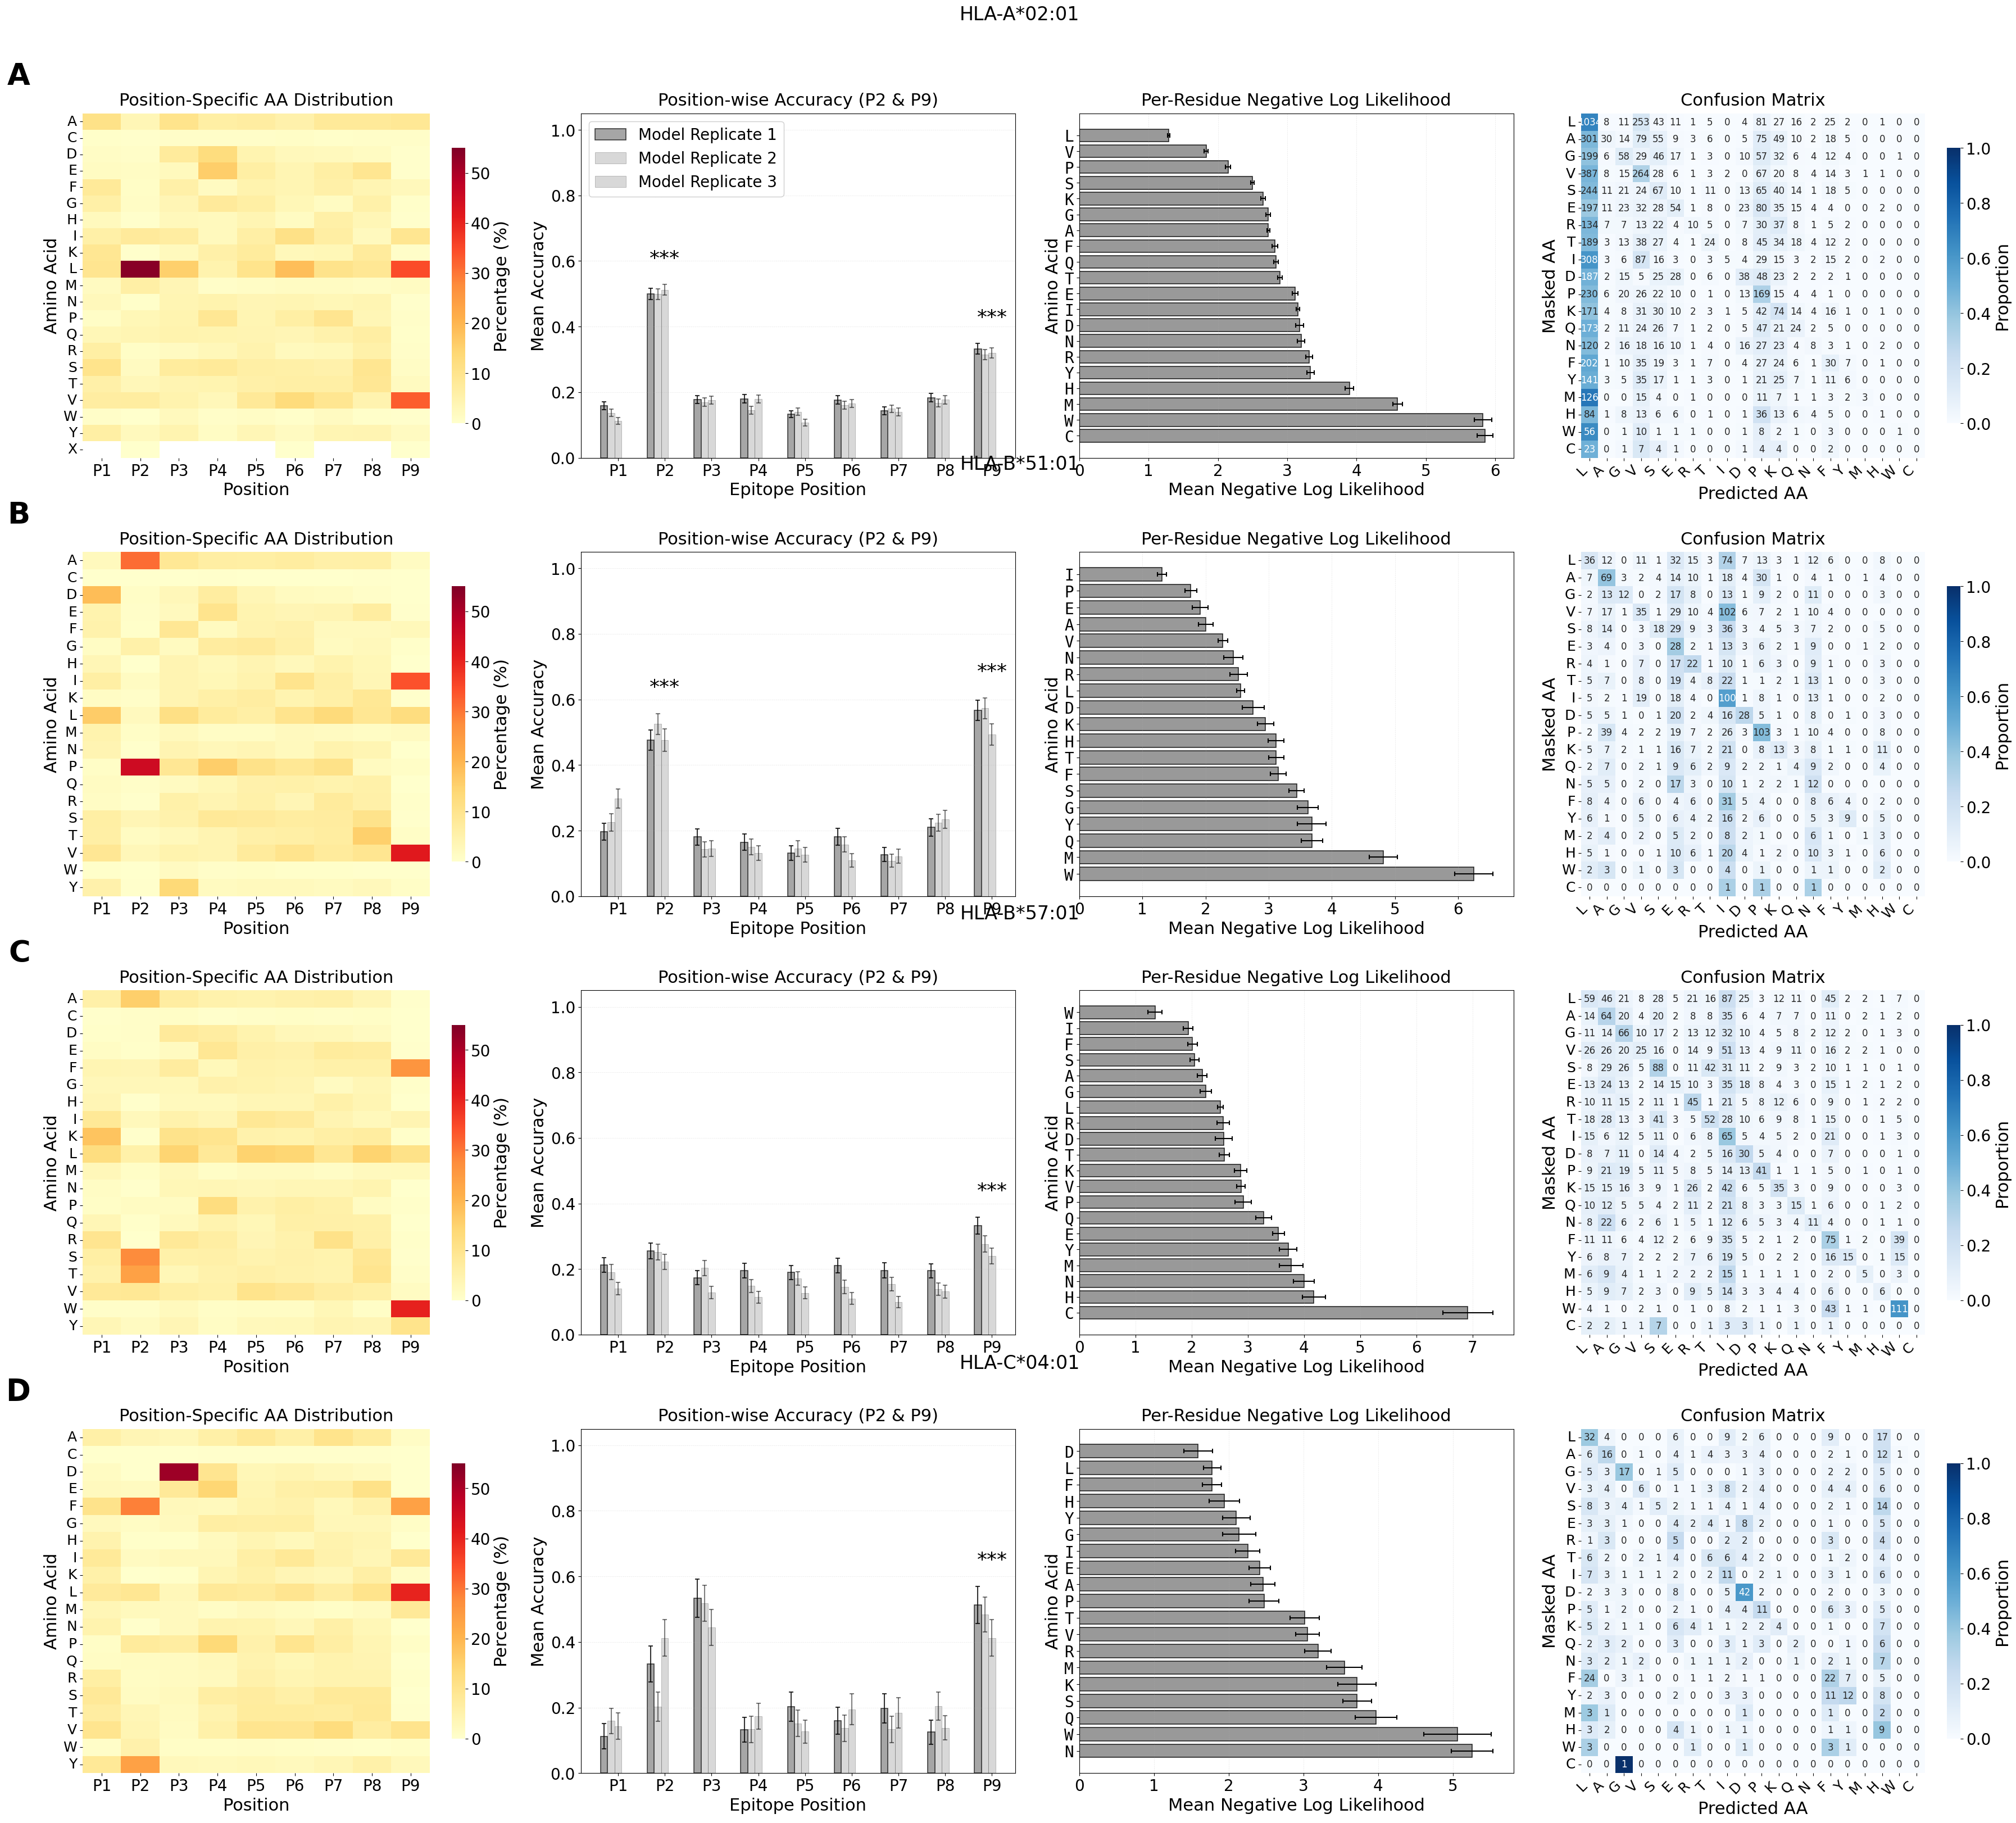

In [4]:
# Create the TRANSPOSED figure (num_alleles rows × 4 columns)
num_alleles = len(allele_analysis_data)
fig = plt.figure(figsize=(36, 8 * num_alleles))

allele_names = list(allele_analysis_data.keys())
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']

# # Add main title at the very top
# fig.suptitle('Continued Pre-training Analysis Across HLA Alleles', 
#              fontsize=32, y=0.995)

for allele_idx, allele_name in enumerate(allele_names):
    data = allele_analysis_data[allele_name]
    best_model = data['best_model']
    top_5_models = data['top_5_models']
    
    # Format HLA name
    hla_formatted = f"HLA-{allele_name[0]}*{allele_name[1:3]}:{allele_name[3:]}"
    
    # Calculate base position for this row
    row_base = allele_idx * 4
    
    # ============================================================================
    # COLUMN 1: Position-Specific Amino Acid Distribution
    # ============================================================================
    ax0 = plt.subplot(num_alleles, 4, row_base + 1)
    
    # Get min/max for this specific allele
    vmin_allele = 0
    vmax_allele = 55
    
    # Plot heatmap with allele-specific scale
    sns.heatmap(length_9_percentages[allele_name],
                annot=False,
                fmt='.1f',
                cmap='YlOrRd',
                cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                ax=ax0,
                vmin=vmin_allele,
                vmax=vmax_allele)
    
    # Add subtitle on top of this plot
    ax0.set_title('Position-Specific AA Distribution', fontsize=22, pad=10)
    
    ax0.set_xlabel('Position', fontsize=22)
    ax0.set_ylabel('Amino Acid', fontsize=22)
    ax0.tick_params(axis='both', which='major', labelsize=20)
    ax0.set_xticklabels(ax0.get_xticklabels(), rotation=0, fontsize=20)
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0, fontsize=18)
    
    # Update colorbar font size
    cbar = ax0.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label('Percentage (%)', size=22)
    
    # Add panel letter on the left (ONCE PER ROW) - BOLD at TOP LEFT
    ax0.text(-0.15, 1.15, panel_labels[allele_idx], transform=ax0.transAxes,
            fontsize=38, va='top', ha='right', weight='bold')

    # Add HLA name CENTERED above the entire row of plots
    # Calculate the center position across all 4 subplots in this row
    # Use figure coordinates to place text above the middle of the row
    fig.text(0.5, 1 - (allele_idx / num_alleles), 
            f'{hla_formatted}',
            fontsize=24, va='bottom', ha='center', transform=fig.transFigure)
    
    # ============================================================================
    # COLUMN 2: Position-wise Accuracy (P2 and P9 highlighted) WITH ERROR BARS
    # ============================================================================
    ax1 = plt.subplot(num_alleles, 4, row_base + 2)
    
    # Add subtitle on top of this plot
    ax1.set_title('Position-wise Accuracy (P2 & P9)', fontsize=22, pad=10)
    
    positions = range(1, 10)
    x_pos = np.arange(len(positions))
    width = 0.15  # Width for each bar
    
    # Plot up to 5 models
    for model_idx, model_name in enumerate(top_5_models):
        pos_acc = data['position_accuracy_all'][model_name]
        pos_stderr = data['position_stderr_all'][model_name]
        
        # Determine color: best model gets colors by position, others get gray
        if model_idx == 0:  # Best model
            colors = [HIGHLIGHT_COLOR if pos in [2, 9] else GRAY_COLOR for pos in positions]
        else:
            colors = [GRAY_COLOR] * len(positions)
        
        offset = (model_idx - 2) * width  # Center around 0
        
        for i, pos in enumerate(positions):
            if pos in pos_acc.index:
                # Get standard error for this position
                stderr = pos_stderr[pos] if pos in pos_stderr.index else 0
                
                ax1.bar(x_pos[i] + offset, pos_acc[pos], width,
                       color=colors[i], alpha=0.7 if model_idx == 0 else 0.3,
                       edgecolor='black', linewidth=1.2 if model_idx == 0 else 0.5,
                       label=f'Model Replicate {model_idx+1}' if i == 0 else "")
                
                # Add error bars
                ax1.errorbar(x_pos[i] + offset, pos_acc[pos], yerr=stderr,
                           fmt='none', ecolor='black', capsize=3, capthick=1.5,
                           alpha=0.8 if model_idx == 0 else 0.5)
    
    ax1.set_xlabel('Epitope Position', fontsize=22)
    ax1.set_ylabel('Mean Accuracy', fontsize=22)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'P{p}' for p in positions], fontsize=20)
    ax1.set_ylim(0, 1.05)
    ax1.tick_params(axis='both', which='major', labelsize=20)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add significance markers for P2 and P9
    if allele_name in position_significance:
        for pos_name, stats in position_significance[allele_name].items():
            if stats['significant']:
                pos_num = int(pos_name[1])
                pos_idx = pos_num - 1
                
                # Get the maximum bar height + error bar at this position across all models
                max_height = 0
                for model_idx, model_name in enumerate(top_5_models):
                    pos_acc = data['position_accuracy_all'][model_name]
                    pos_stderr = data['position_stderr_all'][model_name]
                    if pos_num in pos_acc.index:
                        stderr = pos_stderr[pos_num] if pos_num in pos_stderr.index else 0
                        max_height = max(max_height, pos_acc[pos_num] + stderr)
                
                # Place stars above the tallest bar + error
                ax1.text(x_pos[pos_idx], max_height + 0.05, '***',
                        ha='center', va='bottom', fontsize=26,
                        color='black')
    
    if allele_idx == 0:  # Only show legend for first row
        ax1.legend(loc='upper left', fontsize=20, framealpha=0.95)
    
    # ============================================================================
    # COLUMN 3: Per-Residue Perplexity (Best Model Only) WITH ERROR BARS
    # ============================================================================
    ax2 = plt.subplot(num_alleles, 4, row_base + 3)
    
    # Add subtitle on top of this plot
    ax2.set_title('Per-Residue Negative Log Likelihood', fontsize=22, pad=10)
    
    if data['residue_perplexity']:
        perplexity_df = pd.DataFrame(list(data['residue_perplexity'].items()),
                                     columns=['AA', 'Perplexity'])
        
        # Add standard error column
        perplexity_df['StdErr'] = perplexity_df['AA'].map(data['residue_perplexity_stderr'])
        perplexity_df = perplexity_df.sort_values('Perplexity')

        perplexity_df = perplexity_df[~perplexity_df['AA'].str.contains('<')]
        
        # Highlight top 3 lowest perplexity
        colors = [HIGHLIGHT_COLOR if i < 3 else GRAY_COLOR for i in range(len(perplexity_df))]
        
        y_pos = np.arange(len(perplexity_df))
        ax2.barh(y_pos, perplexity_df['Perplexity'], color=colors, alpha=0.8,
                edgecolor='black', linewidth=1.2,
                xerr=perplexity_df['StdErr'], capsize=3, error_kw={'ecolor': 'black', 'capthick': 1.5})
        
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(perplexity_df['AA'], fontsize=20, family='monospace')
        ax2.set_xlabel('Mean Negative Log Likelihood', fontsize=22)
        ax2.set_ylabel('Amino Acid', fontsize=22)
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
        ax2.invert_yaxis()
    else:
        ax2.text(0.5, 0.5, 'Perplexity data not available',
                ha='center', va='center', transform=ax2.transAxes, fontsize=22)
    
    # ============================================================================
    # COLUMN 4: Confusion Matrix (Best Model Only) with Raw Counts - NO LINES
    # ============================================================================
    ax3 = plt.subplot(num_alleles, 4, row_base + 4)
    
    # Add subtitle on top of this plot
    ax3.set_title('Confusion Matrix', fontsize=22, pad=10)

    # Use normalized matrix for coloring
    conf_mat = data['confusion_matrix'].iloc[2:, 2:]

    # Use raw counts for annotations
    conf_mat_raw = data['confusion_matrix_raw'].iloc[2:, 2:]
    annot_text = conf_mat_raw.astype(int).astype(str)

    # Plot confusion matrix WITHOUT lines between cells
    sns.heatmap(conf_mat, annot=annot_text, fmt='s', cmap='Blues', cbar=True,
                square=True, linewidths=0, linecolor=None,  # NO LINES
                cbar_kws={'label': 'Proportion', 'shrink': 0.8},
                ax=ax3, vmin=0, vmax=1,
                annot_kws={'fontsize': 12})

    # Update colorbar label font size
    cbar = ax3.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label('Proportion', size=22)

    ax3.set_xlabel('Predicted AA', fontsize=22)
    ax3.set_ylabel('Masked AA', fontsize=22)
    ax3.tick_params(axis='both', which='major', labelsize=20)

    # Rotate labels for better readability
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=18)
    ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave space at top for main title
plt.savefig('../../figures_manuscript/2_pretraining.pdf', bbox_inches='tight')
plt.show()

In [5]:
data

{'best_model': '_epitope_FT_15_0.001_1e-05_AUG_3_C0401_2',
 'top_5_models': ['_epitope_FT_15_0.001_1e-05_AUG_3_C0401_2',
  '_epitope_FT_25_0.0001_5e-05_AUG_4_C0401_1',
  '_epitope_FT_25_0.0001_1e-06_AUG_4_C0401_2'],
 'position_accuracy_all': {'_epitope_FT_15_0.001_1e-05_AUG_3_C0401_2': position
  0     1.000000
  1     0.112676
  2     0.333333
  3     0.533333
  4     0.132530
  5     0.202381
  6     0.160494
  7     0.197531
  8     0.125000
  9     0.512821
  10    0.813559
  11    0.500000
  12    0.533333
  13    0.375000
  14    0.125000
  15    0.900000
  16    0.000000
  17    0.666667
  18    1.000000
  19    1.000000
  20    1.000000
  22    1.000000
  23    1.000000
  dtype: float64,
  '_epitope_FT_25_0.0001_5e-05_AUG_4_C0401_1': position
  0     1.000000
  1     0.159091
  2     0.202381
  3     0.518072
  4     0.133333
  5     0.151899
  6     0.136986
  7     0.133333
  8     0.204545
  9     0.483146
  10    0.761194
  11    0.450000
  12    0.500000
  13    0.636364
 

In [10]:
def test_position_differences_twostage(allele_data, n_permutations=10000, alpha=0.05):
    """
    Stage 1: Omnibus test - Are positions different at all?
    Stage 2: Post-hoc - Which specific positions differ?
    """
    results = {}
    
    for allele_name, data in allele_data.items():
        best_model = data['best_model']
        df = data['models_data'][best_model]
        df = df[(df['position'] >= 1) & (df['position'] <= 9) & (df['original_id'] > 3)].copy()
        
        if len(df) == 0:
            continue
        
        df['correct'] = (df['original_id'] == df['predicted_id']).astype(int)
        
        # STAGE 1: Omnibus test - is there ANY difference across positions?
        position_accs = df.groupby('position')['correct'].mean()
        obs_variance = position_accs.var()
        
        null_variances = []
        df_perm = df.copy()
        for _ in range(n_permutations):
            df_perm['position'] = np.random.permutation(df['position'].values)
            perm_accs = df_perm.groupby('position')['correct'].mean()
            null_variances.append(perm_accs.var())
        
        omnibus_p = (np.array(null_variances) >= obs_variance).mean()
        
        results[allele_name] = {
            'omnibus_test': {
                'variance': obs_variance,
                'p_value': omnibus_p,
                'significant': omnibus_p < alpha
            },
            'position_tests': {}
        }
        
        # STAGE 2: Only if omnibus is significant, test specific positions
        if omnibus_p < alpha:
            # Test P2 and P9 specifically against others
            for pos in [2, 9]:
                target_acc = df[df['position'] == pos]['correct'].mean()
                other_acc = df[df['position'] != pos]['correct'].mean()
                obs_diff = target_acc - other_acc
                
                null_diffs = []
                for _ in range(n_permutations):
                    df_perm['position'] = np.random.permutation(df['position'].values)
                    perm_target = df_perm[df_perm['position'] == pos]['correct'].mean()
                    perm_other = df_perm[df_perm['position'] != pos]['correct'].mean()
                    null_diffs.append(perm_target - perm_other)
                
                p_val = (np.array(null_diffs) >= obs_diff).mean()
                # Bonferroni for 2 tests only
                p_val_corrected = min(p_val * 2, 1.0)
                
                results[allele_name]['position_tests'][f'P{pos}'] = {
                    'accuracy': target_acc,
                    'other_acc': other_acc,
                    'difference': obs_diff,
                    'p_value': p_val_corrected,
                    'significant': p_val_corrected < alpha
                }
    
    return results
    
# Run significance test
position_significance = test_position_differences_twostage(allele_analysis_data)

In [19]:
# Here's the complete adaptation with the two-stage testing approach:
# python
# Statistical test for position significance - TWO STAGE APPROACH
def test_position_differences_twostage(allele_data, n_permutations=10000, alpha=0.05):
    """
    Stage 1: Omnibus test - Are positions different at all?
    Stage 2: Post-hoc - Which specific positions (P2, P9) differ?
    """
    results = {}
    
    for allele_name, data in allele_data.items():
        best_model = data['best_model']
        df = data['models_data'][best_model]
        df = df[(df['position'] >= 1) & (df['position'] <= 9) & (df['original_id'] > 3)].copy()
        
        if len(df) == 0:
            continue
        
        df['correct'] = (df['original_id'] == df['predicted_id']).astype(int)
        
        # STAGE 1: Omnibus test - is there ANY difference across positions?
        position_accs = df.groupby('position')['correct'].mean()
        obs_variance = position_accs.var()
        
        null_variances = []
        df_perm = df.copy()
        for _ in range(n_permutations):
            df_perm['position'] = np.random.permutation(df['position'].values)
            perm_accs = df_perm.groupby('position')['correct'].mean()
            null_variances.append(perm_accs.var())
        
        omnibus_p = (np.array(null_variances) >= obs_variance).mean()
        
        results[allele_name] = {
            'omnibus_test': {
                'variance': obs_variance,
                'p_value': omnibus_p,
                'significant': omnibus_p < alpha
            },
            'position_tests': {}
        }
        
        # STAGE 2: Only if omnibus is significant, test ALL positions
        if omnibus_p < alpha:
            # Test all positions 1-9
            for pos in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
                target_acc = df[df['position'] == pos]['correct'].mean()
                other_acc = df[df['position'] != pos]['correct'].mean()
                obs_diff = target_acc - other_acc
                
                null_diffs = []
                for _ in range(n_permutations):
                    df_perm['position'] = np.random.permutation(df['position'].values)
                    perm_target = df_perm[df_perm['position'] == pos]['correct'].mean()
                    perm_other = df_perm[df_perm['position'] != pos]['correct'].mean()
                    null_diffs.append(perm_target - perm_other)
                
                p_val = (np.array(null_diffs) >= obs_diff).mean()
                # Bonferroni for 9 tests (all positions) - THIS IS THE KEY CHANGE
                p_val_corrected = min(p_val * 9, 1.0)
                
                results[allele_name]['position_tests'][f'P{pos}'] = {
                    'accuracy': target_acc,
                    'other_acc': other_acc,
                    'difference': obs_diff,
                    'p_value': p_val,
                    'p_value_corrected': p_val_corrected,
                    'significant': p_val_corrected < alpha
                }
        else:
            print(f"{allele_name}: Omnibus test not significant (p={omnibus_p:.4f}), skipping post-hoc tests")
    return results

# Run two-stage significance test
position_significance = test_position_differences_twostage(allele_analysis_data)



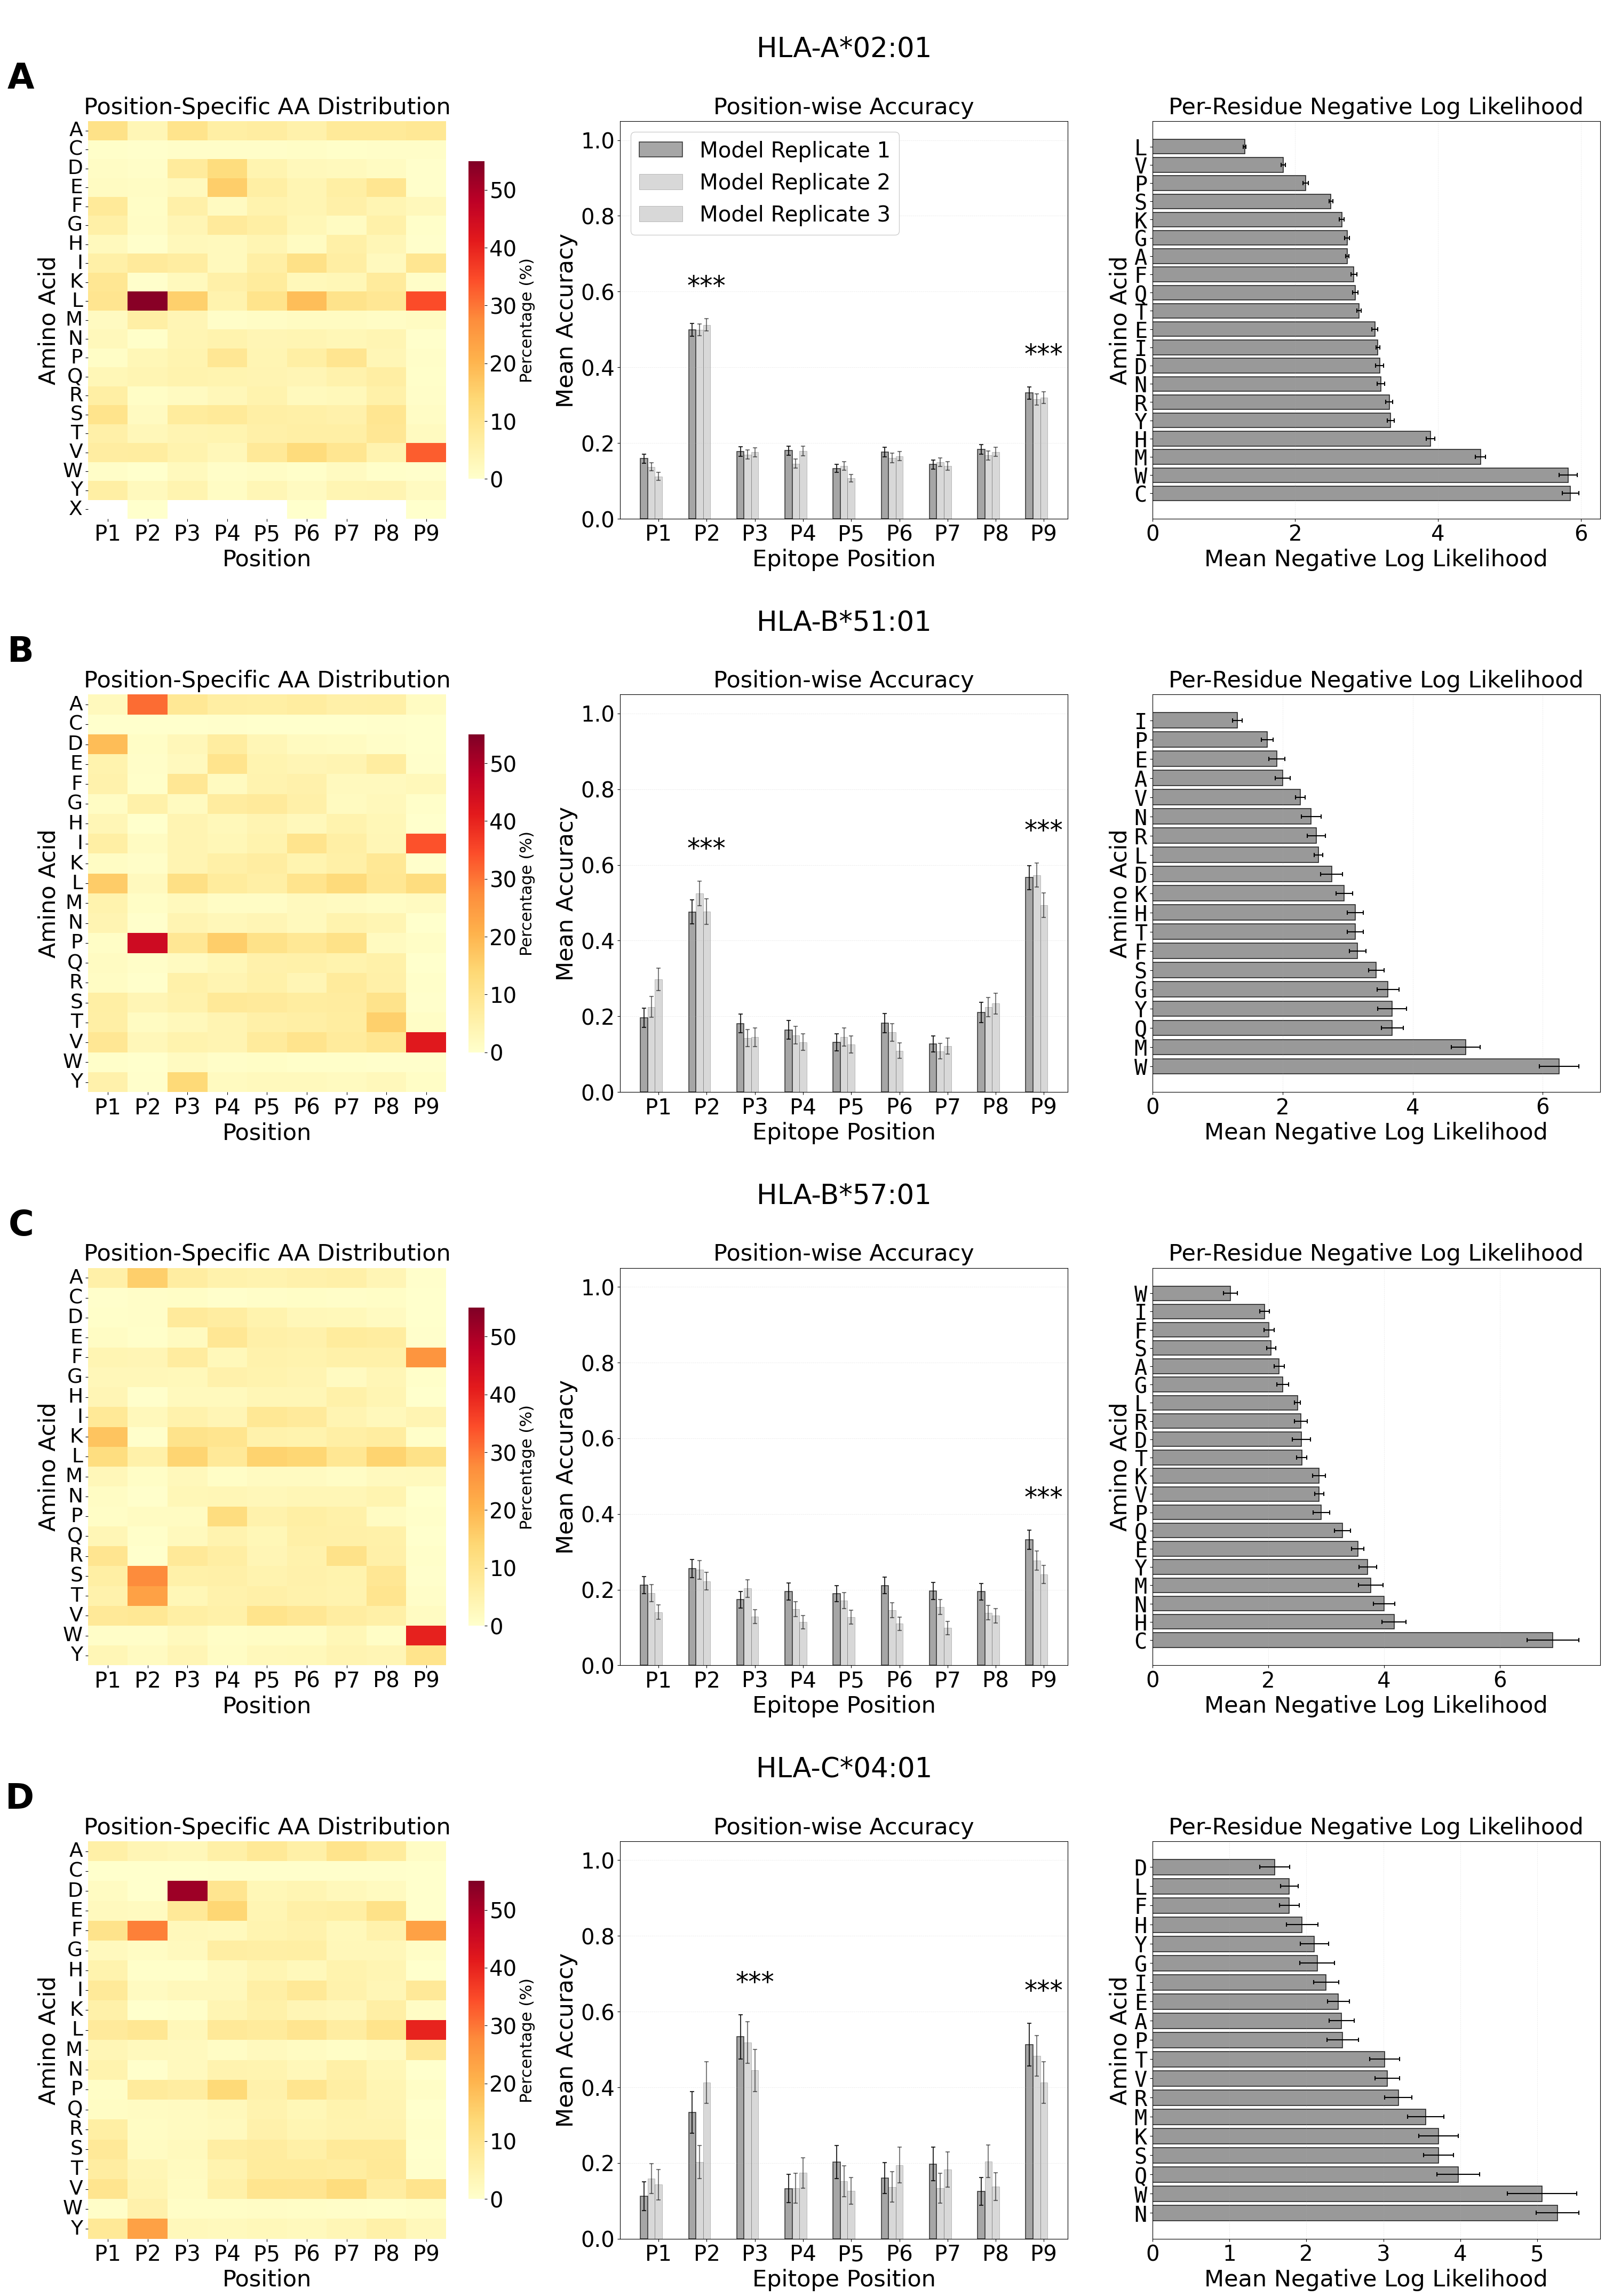

In [20]:

# ============================================================================
# PLOTTING CODE
# ============================================================================
num_alleles = len(allele_analysis_data)
fig = plt.figure(figsize=(30, 11 * num_alleles))
allele_names = list(allele_analysis_data.keys())
panel_labels = ['A', 'B', 'C', 'D']

for allele_idx, allele_name in enumerate(allele_names):
    data = allele_analysis_data[allele_name]
    best_model = data['best_model']
    top_5_models = data['top_5_models']
    
    # Format HLA name
    hla_formatted = f"\nHLA-{allele_name[0]}*{allele_name[1:3]}:{allele_name[3:]}\n"
    
    # Calculate base position for this row (now only 3 columns)
    row_base = allele_idx * 3
    
    # ============================================================================
    # COLUMN 1: Position-Specific Amino Acid Distribution
    # ============================================================================
    ax0 = plt.subplot(num_alleles, 3, row_base + 1)
    
    # Get min/max for this specific allele
    vmin_allele = 0
    vmax_allele = 55
    
    # Plot heatmap with allele-specific scale
    sns.heatmap(length_9_percentages[allele_name],
                annot=False,
                fmt='.1f',
                cmap='YlOrRd',
                cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                ax=ax0,
                vmin=vmin_allele,
                vmax=vmax_allele)
    
    # Add subtitle on top of this plot
    ax0.set_title(f'Position-Specific AA Distribution', fontsize=9+22, pad=10)
    
    ax0.set_xlabel('Position', fontsize=9+22)
    ax0.set_ylabel('Amino Acid', fontsize=9+22)
    ax0.tick_params(axis='both', which='major', labelsize=9+20)
    ax0.set_xticklabels(ax0.get_xticklabels(), rotation=0, fontsize=9+20)
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0, fontsize=9+18)
    
    # Update colorbar font size
    cbar = ax0.collections[0].colorbar
    cbar.ax.tick_params(labelsize=9+20)
    cbar.set_label('Percentage (%)', size=22)
    
    # Add panel letter on the left (ONCE PER ROW) - BOLD at TOP LEFT
    ax0.text(-0.15, 1.15, panel_labels[allele_idx], transform=ax0.transAxes,
            fontsize=9+38, va='top', ha='right', weight='bold')

    # ============================================================================
    # COLUMN 2: Position-wise Accuracy (P2 and P9 highlighted) WITH ERROR BARS
    # ============================================================================
    ax1 = plt.subplot(num_alleles, 3, row_base + 2)
    
    # Add HLA title on top of middle plot
    ax1.text(0.5, 1.07, hla_formatted, transform=ax1.transAxes,
            fontsize=9+28, va='bottom', ha='center', )
    
    # Add subtitle on top of this plot
    ax1.set_title('Position-wise Accuracy', fontsize=9+22, pad=10)
    
    positions = range(1, 10)
    x_pos = np.arange(len(positions))
    width = 0.15  # Width for each bar
    
    # Plot up to 5 models
    for model_idx, model_name in enumerate(top_5_models):
        pos_acc = data['position_accuracy_all'][model_name]
        pos_stderr = data['position_stderr_all'][model_name]
        
        # Determine color: best model gets colors by position, others get gray
        if model_idx == 0:  # Best model
            colors = [HIGHLIGHT_COLOR if pos in [2, 9] else GRAY_COLOR for pos in positions]
        else:
            colors = [GRAY_COLOR] * len(positions)
        
        offset = (model_idx - 2) * width  # Center around 0
        
        for i, pos in enumerate(positions):
            if pos in pos_acc.index:
                # Get standard error for this position
                stderr = pos_stderr[pos] if pos in pos_stderr.index else 0
                
                ax1.bar(x_pos[i] + offset, pos_acc[pos], width,
                       color=colors[i], alpha=0.7 if model_idx == 0 else 0.3,
                       edgecolor='black', linewidth=1.2 if model_idx == 0 else 0.5,
                       label=f'Model Replicate {model_idx+1}' if i == 0 else "")
                
                # Add error bars
                ax1.errorbar(x_pos[i] + offset, pos_acc[pos], yerr=stderr,
                           fmt='none', ecolor='black', capsize=3, capthick=1.5,
                           alpha=0.8 if model_idx == 0 else 0.5)
    
    ax1.set_xlabel('Epitope Position', fontsize=9+22)
    ax1.set_ylabel('Mean Accuracy', fontsize=9+22)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'P{p}' for p in positions], fontsize=9+20)
    ax1.set_ylim(0, 1.05)
    ax1.tick_params(axis='both', which='major', labelsize=9+20)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add significance markers for P2 and P9 - UPDATED FOR TWO-STAGE TEST
    if allele_name in position_significance:
        allele_results = position_significance[allele_name]
        # Only show stars if omnibus test passed AND specific position is significant
        if allele_results['omnibus_test']['significant']:
            for pos_name, stats in allele_results['position_tests'].items():
                if stats['significant']:
                    pos_num = int(pos_name[1])
                    pos_idx = pos_num - 1
                    
                    # Get the maximum bar height + error bar at this position across all models
                    max_height = 0
                    for model_idx, model_name in enumerate(top_5_models):
                        pos_acc = data['position_accuracy_all'][model_name]
                        pos_stderr = data['position_stderr_all'][model_name]
                        if pos_num in pos_acc.index:
                            stderr = pos_stderr[pos_num] if pos_num in pos_stderr.index else 0
                            max_height = max(max_height, pos_acc[pos_num] + stderr)
                    
                    # Place stars above the tallest bar + error
                    ax1.text(x_pos[pos_idx], max_height + 0.05, '***',
                            ha='center', va='bottom', fontsize=9+26,
                            color='black')
    
    if allele_idx == 0:  # Only show legend for first row
        ax1.legend(loc='upper left', fontsize=9+20, framealpha=0.95)
    
    # ============================================================================
    # COLUMN 3: Per-Residue Perplexity (Best Model Only) WITH ERROR BARS
    # ============================================================================
    ax2 = plt.subplot(num_alleles, 3, row_base + 3)
    
    # Add subtitle on top of this plot
    ax2.set_title('Per-Residue Negative Log Likelihood', fontsize=9+22, pad=10)
    
    if data['residue_perplexity']:
        perplexity_df = pd.DataFrame(list(data['residue_perplexity'].items()),
                                     columns=['AA', 'Perplexity'])
        
        # Add standard error column
        perplexity_df['StdErr'] = perplexity_df['AA'].map(data['residue_perplexity_stderr'])
        perplexity_df = perplexity_df.sort_values('Perplexity')
        perplexity_df = perplexity_df[~perplexity_df['AA'].str.contains('<')]
        
        # Highlight top 3 lowest perplexity
        colors = [HIGHLIGHT_COLOR if i < 3 else GRAY_COLOR for i in range(len(perplexity_df))]
        
        y_pos = np.arange(len(perplexity_df))
        ax2.barh(y_pos, perplexity_df['Perplexity'], color=colors, alpha=0.8,
                edgecolor='black', linewidth=1.2,
                xerr=perplexity_df['StdErr'], capsize=3, error_kw={'ecolor': 'black', 'capthick': 1.5})
        
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(perplexity_df['AA'], fontsize=9+20, family='monospace')
        ax2.set_xlabel('Mean Negative Log Likelihood', fontsize=9+22)
        ax2.set_ylabel('Amino Acid', fontsize=9+22)
        ax2.tick_params(axis='both', which='major', labelsize=9+20)
        ax2.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
        ax2.invert_yaxis()
    else:
        ax2.text(0.5, 0.5, 'Perplexity data not available',
                ha='center', va='center', transform=ax2.transAxes, fontsize=9+22)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('../../figures_manuscript/2_pretraining_main.pdf', bbox_inches='tight')
plt.show()

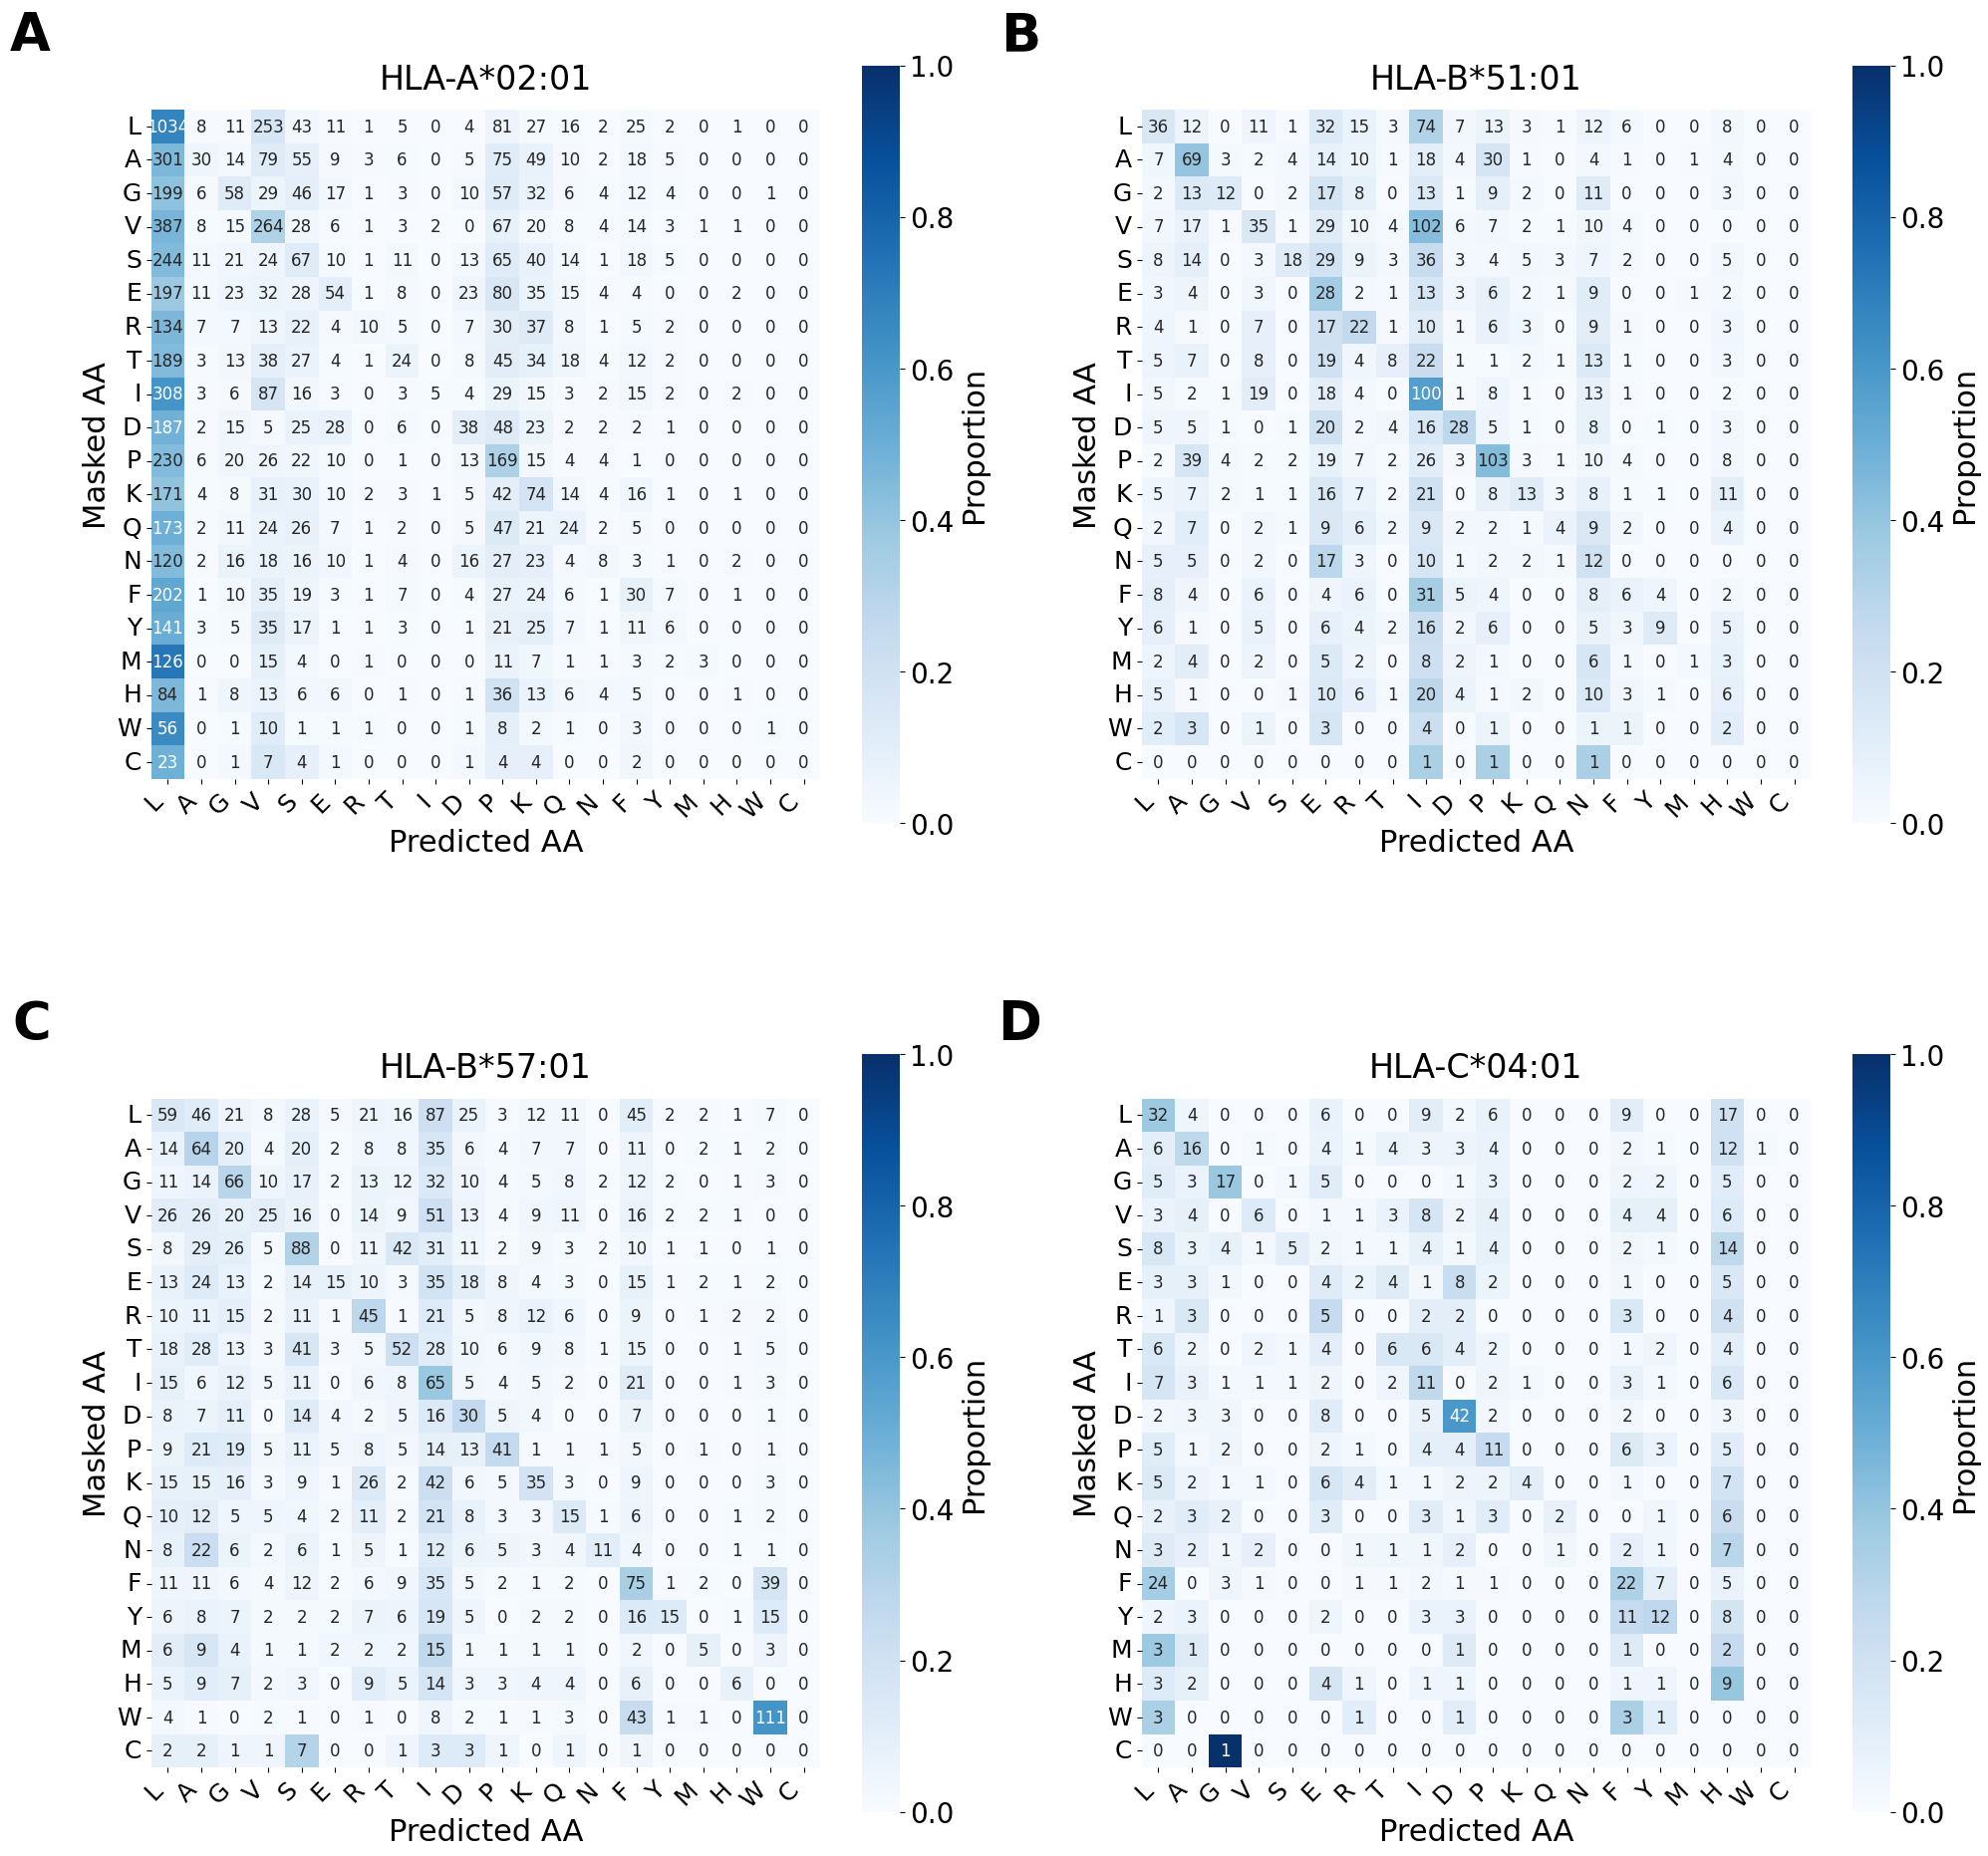

In [ ]:
num_alleles = len(allele_analysis_data)
fig = plt.figure(figsize=(20, 20))
allele_names = list(allele_analysis_data.keys())
panel_labels = ['A', 'B', 'C', 'D']

for allele_idx, allele_name in enumerate(allele_names):
    data = allele_analysis_data[allele_name]
    
    # Format HLA name
    hla_formatted = f"HLA-{allele_name[0]}*{allele_name[1:3]}:{allele_name[3:]}"
    
    # Create subplot in 2x2 grid
    ax = plt.subplot(2, 2, allele_idx + 1)
    
    # Add panel letter at TOP LEFT - BOLD
    ax.text(-0.15, 1.15, panel_labels[allele_idx], transform=ax.transAxes,
            fontsize=38, va='top', ha='right', weight='bold')
    
    # Add HLA name as title
    ax.set_title(f'{hla_formatted}', fontsize=24, pad=15)#, weight='bold')
    
    # Use normalized matrix for coloring
    conf_mat = data['confusion_matrix'].iloc[2:, 2:]
    # Use raw counts for annotations
    conf_mat_raw = data['confusion_matrix_raw'].iloc[2:, 2:]
    annot_text = conf_mat_raw.astype(int).astype(str)
    
    # Plot confusion matrix WITHOUT lines between cells
    sns.heatmap(conf_mat, annot=annot_text, fmt='s', cmap='Blues', cbar=True,
                square=True, linewidths=0, linecolor=None,
                cbar_kws={'label': 'Proportion', 'shrink': 0.8},
                ax=ax, vmin=0, vmax=1,
                annot_kws={'fontsize': 12})
    
    # Update colorbar label font size
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label('Proportion', size=22)
    
    ax.set_xlabel('Predicted AA', fontsize=22)
    ax.set_ylabel('Masked AA', fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Rotate labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=18)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=18)

plt.tight_layout()
plt.savefig('../../figures_manuscript/2_pretraining_confusion_matrices.pdf', bbox_inches='tight')
plt.show()

In [ ]:
break

In [ ]:
### Other code 

In [ ]:
# directory = '/global/scratch/users/sergiomar10/logs/ESMC_Pretrain_logs_09042025'
# csv_files = glob.glob(os.path.join(directory, '*.csv'))
# data = []

# for file in csv_files:
#     if os.path.getsize(file) > 0:
#         try:
#             df = pd.read_csv(file)
#             df = df.replace([np.inf, -np.inf], np.nan).dropna()
#             base = os.path.basename(file)
            
#             name_parts = os.path.splitext(base)[0].split('_')
            
#             if len(name_parts) >= 11:
#                 encoding = name_parts[3]
#                 blocks_unfrozen = int(name_parts[5])
#                 base_block_lr = float(name_parts[6])
#                 regression_block_lr = float(name_parts[7])
#                 num_augmentations = int(name_parts[9])
#                 hla_allele = name_parts[10]
#             else:
#                 encoding = 'Unknown'
#                 blocks_unfrozen = None
#                 base_block_lr = None
#                 regression_block_lr = None
#                 num_augmentations = None
#                 hla_allele = 'Unknown'
            
#             max_val_acc = df['Val Acc'].max() if 'Val Acc' in df.columns else None
            
#             train_loss_values = None
#             train_loss_columns = ['Train Loss', '**Train Loss', 'train_loss', 'Train_Loss']
            
#             for col_name in train_loss_columns:
#                 if col_name in df.columns:
#                     train_loss_values = df[col_name].tolist()
#                     break
            
#             data.append({
#                 'file': file,
#                 'filename': base,
#                 'encoding': encoding,
#                 'blocks_unfrozen': blocks_unfrozen,
#                 'base_block_lr': base_block_lr,
#                 'regression_block_lr': regression_block_lr,
#                 'num_augmentations': num_augmentations,
#                 'HLA_allele': hla_allele,
#                 'max_val_acc': max_val_acc,
#                 'train_losses': train_loss_values
#             })
            
#         except Exception as e:
#             continue

# df_summary = pd.DataFrame(data)

In [ ]:
# df_summary['BU_HLA'] = df_summary['base_block_lr'].astype(str) + ' + ' + df_summary['encoding'].astype(str)
# df_summary['HLA_allele']  = df_summary['HLA_allele'].str.replace('HLA', '')
# allele_encoding_map = df_summary.groupby('HLA_allele')['encoding'].unique()

# # Find alleles that have both models
# complete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) == {'HLA', 'epitope'})]

# # Find alleles missing either model
# incomplete = allele_encoding_map[allele_encoding_map.apply(lambda x: set(x) != {'HLA', 'epitope'})]

# print("✅ HLA alleles with both HLA and epitope models:")
# print(complete)

# print("\n⚠️ HLA alleles missing one of the models:")
# print(incomplete)

In [ ]:
# HLAs_done = Counter([x.split('AUG')[1].split('_')[2] for x in  glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_evals/*.csv')]).keys()

In [ ]:
# import time
# import itertools

# summary = []

# for HLA in HLAs_done:
#     HLA = HLA.replace('HLA','')
#     # 1. Load all CSV files into a dictionary of DataFrames.
#     trained_files = glob.glob(f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*{HLA}*.csv')
#     trained_files = sorted(trained_files)

#     print(f"Found {len(trained_files)} files.")

#     models = {}
#     model_names = []
#     for file in trained_files:

#         if os.path.getsize(file) < 10:
#             print(f"Skipping empty file: {file}")
#             continue

#         df = pd.read_csv(file)
        
#         base = os.path.basename(file)
#         # Remove common prefix and suffix to get a shorter model name.
#         # For example: "training_log_ESMMASK_" and ".csv"
#         name = base.replace("ESMMASK", "").replace(".csv", "").split('_HLA')[0]
#         models[name] = df
#         model_names.append(name)

#         # Summarize average token_nll for each model
#         avg_nll = df['token_nll'].mean()

#         summary.append({
#         'File': os.path.basename(file),
#         'HLA': HLA,
#         'Avg_Token_NLL': avg_nll
#     })
#     # for name, df in models.items():
#     #     avg_nll[name] = df['token_nll'].mean()

#     # # Sort by lowest average negative log-likelihood
#     # best_models_by_nll = sorted(avg_nll.items(), key=lambda x: x[1])
#     # print("Best models by average token NLL:")
#     # for name, score in best_models_by_nll:
#     #     print(f"{name}: {score:.4f}")

# summary_df = pd.DataFrame(summary)
# summary_df = summary_df.sort_values(by='Avg_Token_NLL')

In [ ]:
# sum_subset = summary_df[summary_df['Avg_Token_NLL'] > 0 ]

In [ ]:
# # Step 1: Load models
# trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B5701*.csv')
# trained_files = sorted(trained_files)
# print(f"Found {len(trained_files)} files.")

# models = {}
# accuracies = {}
# model_names = []

# for file in trained_files:
#     df = pd.read_csv(file)
#     base = os.path.basename(file)
#     name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
#     models[name] = df
#     model_names.append(name)

#     # Compute accuracy
#     if 'original_id' in df.columns and 'predicted_id' in df.columns:
#         accuracy = (df['original_id'] == df['predicted_id']).mean()
#         accuracies[name] = accuracy
#         print(f"{name}: Accuracy = {accuracy:.3f}")

# # Step 2: Select best model (based on accuracy)
# best_model = max(accuracies, key=accuracies.get)
# print(f"\nBest model: {best_model} with accuracy {accuracies[best_model]:.3f}")

# # Step 3: Compare best model to all others and compute delta log perplexity
# comparison_stats = []

# for other_model in model_names:
#     if other_model == best_model:
#         continue

#     df1 = models[best_model]
#     df2 = models[other_model]

#     df_merged = pd.merge(df1, df2, on=['epitope', 'original_id'], how='inner',
#                          suffixes=('_model1', '_model2'))

#     # df_merged = df_merged[df_merged['position_model1'] != 0]
#     # df_merged = df_merged[(df_merged['position_model1'] == 2 | (df_merged['position_model1'] == 9) ) ]
#     # df_merged = df_merged[(df_merged['position_model1'] == df_merged['position_model2'])] 

#     df_merged['delta_log_ppl'] = df_merged['token_nll_model1'] - df_merged['token_nll_model2']

#     df_merged = df_merged.replace([np.inf, -np.inf], np.nan).dropna()

#     acc_model1 = (df_merged['original_id'] == df_merged['predicted_id_model1']).mean()
#     acc_model2 = (df_merged['original_id'] == df_merged['predicted_id_model2']).mean()

#     mean_delta = np.abs(df_merged['delta_log_ppl']).mean()

#     comparison_stats.append({
#         'model2': other_model,
#         'acc_model1': acc_model1,
#         'acc_model2': acc_model2,
#         'mean_delta_log_ppl': mean_delta,
#         'df_merged': df_merged
#     })

# # Step 4: Sort comparisons by mean delta log perplexity and take top 5
# top_comparisons = sorted(comparison_stats, key=lambda x: -x['mean_delta_log_ppl'])[:5]

# # Step 5: Plot
# fig, axes = plt.subplots(1, 5, figsize=(30, 5), squeeze=False)

# for i, comp in enumerate(top_comparisons):
#     ax = axes[0, i]
#     df_merged = comp['df_merged']
    
#     scatter_obj = ax.scatter(
#         df_merged['predicted_prob_model1'],
#         df_merged['predicted_prob_model2'],
#         c=df_merged['delta_log_ppl'],
#         cmap='coolwarm',
#         s=40,
#         edgecolor='k'
#     )
#     ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
#     ax.set_xlim(-0.1, 1.1)
#     ax.set_ylim(-0.1, 1.1)

#     ax.set_xlabel(f"{best_model}\nAcc: {comp['acc_model1']:.2%}")
#     ax.set_ylabel(f"{comp['model2']}\nAcc: {comp['acc_model2']:.2%}")
#     # ax.set_title(f"ΔlogPPL Mean: {comp['mean_delta_log_ppl']:.2f}")
#     ax.set_title(f"ΔlogPPL: {comp['mean_delta_log_ppl']:.2f}\n(n={len(df_merged)})")

# # Colorbar
# fig.subplots_adjust(right=0.88)
# cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
# fig.colorbar(scatter_obj, cax=cbar_ax, label="Δ log Perplexity [Best - Other]")

# fig.suptitle(f"Best Model: {best_model} vs Top 5 Contrasts", fontsize=16)
# plt.tight_layout(rect=[0, 0, 0.88, 1])

# # # Save the figure with the HLA name in the specified folder.
# # out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# # out_dir.mkdir(parents=True, exist_ok=True)      
# # save_path = out_dir / f"fig2a.pdf"
# # fig = plt.gcf()                                 # or keep a handle from plt.subplots()
# # fig.savefig(save_path, dpi=300, bbox_inches="tight")
# # plt.close(fig)   

# plt.show()


In [ ]:
# trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*A0201*.csv')
# trained_files = sorted(trained_files)
# # print(f"Found {len(trained_files)} files.")

# models = {}
# accuracies = {}
# model_names = []

# for file in trained_files:
#     # Check if file exists and is not empty
#     if not os.path.exists(file) or os.path.getsize(file) < 10:
#         # print(f"Skipping empty or non-existent file: {file}")
#         continue
    
#     try:
#         df = pd.read_csv(file)
        
#         # Check required columns exist
#         required_columns = ['original_id', 'predicted_id']
#         if not all(col in df.columns for col in required_columns):
#             # print(f"Missing required columns in {file}: {df.columns.tolist()}")
#             continue
        
#         base = os.path.basename(file)
#         name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
        
#         # Clean the name further if needed
#         name = name.replace("training_log_", "").replace("_", "")
        
#         models[name] = df
#         model_names.append(name)
        
#         # Compute accuracy
#         accuracy = (df['original_id'] == df['predicted_id']).mean()
#         accuracies[name] = accuracy
#         # print(f"{name}: Accuracy = {accuracy:.3f}")
        
#     except Exception as e:
#         # print(f"Error reading {file}: {e}")
#         continue

# # Check if we have any valid models
# if not models:
#     raise ValueError("No valid model files found!")

# # Step 2: Select best model (based on accuracy)
# best_model = max(accuracies, key=accuracies.get)
# # print(f"\nBest model: {best_model} with accuracy {accuracies[best_model]:.3f}")

# # Step 3: Compare best model to all others and compute delta log perplexity
# comparison_stats = []

# for other_model in model_names:
#     if other_model == best_model:
#         continue
    
#     try:
#         df1 = models[best_model]
#         df2 = models[other_model]
        
#         # Check required columns for merge
#         merge_columns = ['epitope', 'original_id']
#         if not all(col in df1.columns and col in df2.columns for col in merge_columns):
#             # print(f"Missing merge columns for {other_model}")
#             continue
            
#         df_merged = pd.merge(df1, df2, on=merge_columns, how='inner',
#                            suffixes=('_model1', '_model2'))
        
#         if len(df_merged) == 0:
#             # print(f"No matching data between {best_model} and {other_model}")
#             continue
        
#         # Filter for matching positions
#         if 'position_model1' in df_merged.columns and 'position_model2' in df_merged.columns:
#             df_merged = df_merged[df_merged['position_model1'] == df_merged['position_model2']]
        
#         # Optional position filtering (uncomment and modify as needed)
#         df_merged = df_merged[df_merged['original_id'] > 3]

#         df_merged = df_merged[df_merged['position_model1'] < 10]
#         df_merged['perplexity_model1'] = np.exp(df_merged['token_nll_model1'])
#         df_merged = df_merged[df_merged['perplexity_model1'] < 20]
        
#         df_merged = df_merged[(df_merged['predicted_id_model1'] == df_merged['predicted_id_model2']) & (df_merged['predicted_id_model2'] == df_merged['original_id'])]
#         # df_merged = df_merged[(df_merged['position_model1'] == 2) | (df_merged['position_model1'] == 9)]
        
#         # Check required columns for NLL calculation
#         if 'token_nll_model1' not in df_merged.columns or 'token_nll_model2' not in df_merged.columns:
#             # print(f"Missing token_nll columns for {other_model}")
#             continue
            
#         # Compute delta log perplexity
#         df_merged['delta_log_ppl'] = df_merged['token_nll_model2'] - df_merged['token_nll_model1']

#         # Clean infinite and NaN values
#         df_merged = df_merged.replace([np.inf, -np.inf], np.nan).dropna()

        
        
#         if len(df_merged) == 0:
#             # print(f"No valid data after cleaning for {other_model}")
#             continue
        
#         # Compute accuracies on merged data
#         acc_model1 = (df_merged['original_id'] == df_merged['predicted_id_model1']).mean()
#         acc_model2 = (df_merged['original_id'] == df_merged['predicted_id_model2']).mean()
#         mean_delta = np.abs(df_merged['delta_log_ppl']).mean()
        
#         comparison_stats.append({
#             'model2': other_model,
#             'acc_model1': acc_model1,
#             'acc_model2': acc_model2,
#             'mean_delta_log_ppl': mean_delta,
#             'df_merged': df_merged
#         })
        
#     except Exception as e:
#         # print(f"Error comparing {best_model} vs {other_model}: {e}")
#         continue

# # Check if we have any valid comparisons
# if not comparison_stats:
#     raise ValueError("No valid model comparisons found!")

# # Step 4: Sort comparisons by mean delta log perplexity and take top 5
# top_comparisons = sorted(comparison_stats, key=lambda x: -x['mean_delta_log_ppl'])[:5]

# # print(f"\nFound {len(comparison_stats)} valid comparisons, plotting top 5")

# # Step 5: Plot
# fig, axes = plt.subplots(1, len(top_comparisons), figsize=(6*len(top_comparisons), 5))

# # Handle case where there's only one comparison
# if len(top_comparisons) == 1:
#     axes = [axes]

# for i, comp in enumerate(top_comparisons):
#     ax = axes[i]
#     df_merged = comp['df_merged']
    
#     # Check required columns for plotting
#     if 'predicted_prob_model1' not in df_merged.columns or 'predicted_prob_model2' not in df_merged.columns:
#         # print(f"Missing predicted_prob columns for {comp['model2']}")
#         continue
    
#     scatter_obj = ax.scatter(
#         df_merged['predicted_prob_model1'],
#         df_merged['predicted_prob_model2'],
#         c=df_merged['position_model1'],
#         cmap='tab10',
#         s=40,
#         edgecolor='k',
#         linewidth=0.5
#     )
    
#     # Add diagonal reference line
#     ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
#     # Set axis limits and labels
#     ax.set_xlim(-0.05, 1.05)
#     ax.set_ylim(-0.05, 1.05)
#     ax.set_xlabel(f"{best_model}\nAcc: {comp['acc_model1']:.2%}")
#     ax.set_ylabel(f"{comp['model2']}\nAcc: {comp['acc_model2']:.2%}")
#     # ax.set_title(f"ΔlogPPL: {comp['mean_delta_log_ppl']:.2f}\n(n={len(df_merged)})")
    
#     # Add grid for better readability
#     ax.grid(True, alpha=0.3)

# # Add colorbar
# fig.subplots_adjust(right=0.88)
# cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
# cbar = fig.colorbar(scatter_obj, cax=cbar_ax, label="Epitope Position")# Δ log Perplexity [Best - Other]

# # Set main title
# fig.suptitle(f"Best Model: {best_model} vs Top {len(top_comparisons)} Contrasts", fontsize=16)
# plt.tight_layout(rect=[0, 0, 0.88, 1])

# # Uncomment to save figure
# # out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# # out_dir.mkdir(parents=True, exist_ok=True)
# # save_path = out_dir / f"fig2a.pdf"
# # fig.savefig(save_path, dpi=300, bbox_inches="tight")
# # plt.close(fig)

# plt.show()


In [ ]:
# df_merged[(df_merged['predicted_id_model1'] == df_merged['predicted_id_model2']) & (df_merged['predicted_id_model2'] == df_merged['original_id'])]

In [ ]:
# trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B5701*.csv')
# trained_files = sorted(trained_files)


In [ ]:
# Counter([x.split('AUG_')[1].split('_')[1] for x in glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*.csv')])

In [ ]:
# trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/*B5101*.csv') #B5101 B5701
# trained_files = sorted(trained_files)


In [ ]:
# models = {}
# accuracies = {}
# model_names = []
# model_info = {}

# for file in trained_files:
#     if not os.path.exists(file) or os.path.getsize(file) < 10:
#         continue
    
#     try:
#         df = pd.read_csv(file)
#         required_columns = ['original_id', 'predicted_id']
#         if not all(col in df.columns for col in required_columns):
#             continue
        
#         base = os.path.basename(file)
#         name = base.replace("ESMMASK", "").replace("_per_token_metrics.csv", "")
#         name = name.replace("training_log_", "")
        
#         models[name] = df
#         model_names.append(name)
#         accuracy = (df['original_id'] == df['predicted_id']).mean()
#         accuracies[name] = accuracy
        
#         encoding, layers = extract_model_info(name)
#         model_info[name] = {'encoding': encoding, 'layers': layers}
        
#     except Exception as e:
#         continue

# if not models:
#     raise ValueError("No valid model files found!")


# # Filter models to only those with at least 10 training epochs
# valid_models = {}
# if 'df_summary' in globals():
#     for model_name, accuracy in accuracies.items():
#         losses = find_training_losses(model_name, df_summary)
#         if losses is not None and len(losses) >= 10:
#             valid_models[model_name] = accuracy

# if valid_models:
#     best_model = max(valid_models, key=valid_models.get)
# else:
#     best_model = max(accuracies, key=accuracies.get)
# comparison_stats = []

# for other_model in model_names:
#     if other_model == best_model:
#         continue
    
#     # Check if comparison model also has at least 10 training epochs
#     if 'df_summary' in globals():
#         other_losses = find_training_losses(other_model, df_summary)
#         if other_losses is None or len(other_losses) < 10:
#             continue
    
#     try:
#         df1 = models[best_model]
#         df2 = models[other_model]
        
#         merge_columns = ['epitope', 'original_id']
#         if not all(col in df1.columns and col in df2.columns for col in merge_columns):
#             continue
            
#         df_merged = pd.merge(df1, df2, on=merge_columns, how='inner',
#                            suffixes=('_model1', '_model2'))
        
#         if len(df_merged) == 0:
#             continue
        
#         if 'position_model1' in df_merged.columns and 'position_model2' in df_merged.columns:
#             df_merged = df_merged[df_merged['position_model1'] == df_merged['position_model2']]
        
#         df_merged = df_merged[df_merged['original_id'] > 3]
#         df_merged = df_merged[df_merged['position_model1'] < 10]
        
#         df_merged['model1_correct'] = (df_merged['original_id'] == df_merged['predicted_id_model1'])
#         df_merged['model2_correct'] = (df_merged['original_id'] == df_merged['predicted_id_model2'])
#         df_merged['agreement'] = (df_merged['predicted_id_model1'] == df_merged['predicted_id_model2'])
        
#         conditions = [
#             (df_merged['model1_correct'] & df_merged['model2_correct']),
#             (~df_merged['model1_correct'] & ~df_merged['model2_correct'] & df_merged['agreement']),
#             (~df_merged['model1_correct'] & ~df_merged['model2_correct'] & ~df_merged['agreement']),
#             (df_merged['model1_correct'] & ~df_merged['model2_correct']),
#             (~df_merged['model1_correct'] & df_merged['model2_correct'])
#         ]
#         choices = ['Both Correct', 'Both Wrong (Same)', 'Both Wrong (Different)', 'M1 Right, M2 Wrong', 'M1 Wrong, M2 Right']
#         df_merged['outcome_category'] = np.select(conditions, choices, default='Other')
        
#         if 'token_nll_model1' not in df_merged.columns or 'token_nll_model2' not in df_merged.columns:
#             continue
            
#         df_merged = df_merged.replace([np.inf, -np.inf], np.nan).dropna()
        
#         if len(df_merged) == 0:
#             continue
        
#         acc_model1 = (df_merged['original_id'] == df_merged['predicted_id_model1']).mean()
#         acc_model2 = (df_merged['original_id'] == df_merged['predicted_id_model2']).mean()
        
#         comparison_stats.append({
#             'model2': other_model,
#             'acc_model1': acc_model1,
#             'acc_model2': acc_model2,
#             'df_merged': df_merged
#         })
        
#     except Exception as e:
#         continue

# if not comparison_stats:
#     raise ValueError("No valid model comparisons found!")

# top_comparisons = comparison_stats[:3]

# fig = plt.figure(figsize=(24, 32))

# for i, comp in enumerate(top_comparisons):
#     df_merged = comp['df_merged']
    
#     if 'predicted_prob_model1' not in df_merged.columns or 'predicted_prob_model2' not in df_merged.columns:
#         continue
    
#     model1_info = model_info.get(best_model, {'encoding': 'Unknown', 'layers': 'Unknown'})
#     model2_info = model_info.get(comp['model2'], {'encoding': 'Unknown', 'layers': 'Unknown'})
    
# for i, comp in enumerate(top_comparisons):
#     df_merged = comp['df_merged']
    
#     if 'predicted_prob_model1' not in df_merged.columns or 'predicted_prob_model2' not in df_merged.columns:
#         continue
    
#     model1_info = model_info.get(best_model, {'encoding': 'Unknown', 'layers': 'Unknown'})
#     model2_info = model_info.get(comp['model2'], {'encoding': 'Unknown', 'layers': 'Unknown'})
    
#     # Row 1: Training Loss Curves
#     ax_loss = plt.subplot(7, 3, i + 1)

#     # Try to find training losses for both models
#     if 'df_summary' in globals():
#         losses_m1 = find_training_losses(best_model, df_summary)
#         losses_m2 = find_training_losses(comp['model2'], df_summary)
        
#         if losses_m1 is not None:
#             epochs_m1 = range(1, len(losses_m1) + 1)
#             ax_loss.plot(epochs_m1, losses_m1, 'o-', color='blue', alpha=0.7, 
#                         linewidth=3, markersize=6, label=f'M1: {model1_info["encoding"]}_FT{model1_info["layers"]}')
        
#         if losses_m2 is not None:
#             epochs_m2 = range(1, len(losses_m2) + 1)
#             ax_loss.plot(epochs_m2, losses_m2, 's-', color='red', alpha=0.7, 
#                         linewidth=3, markersize=6, label=f'M2: {model2_info["encoding"]}_FT{model2_info["layers"]}')
        
#         if losses_m1 is not None or losses_m2 is not None:
#             ax_loss.set_xlabel('Epoch', fontsize=14)
#             ax_loss.set_ylabel('Training Loss', fontsize=14)
#             ax_loss.set_title('Training Loss Curves', fontsize=16)
#             ax_loss.legend(fontsize=12)
#             ax_loss.tick_params(axis='both', which='major', labelsize=12)
#             ax_loss.set_yscale('log')
#         else:
#             ax_loss.text(0.5, 0.5, 'Training loss data\nnot available', 
#                         ha='center', va='center', transform=ax_loss.transAxes, fontsize=14)
#             ax_loss.set_title('Training Loss Curves', fontsize=16)
#     else:
#         ax_loss.text(0.5, 0.5, 'df_summary not found\nCannot plot training losses', 
#                     ha='center', va='center', transform=ax_loss.transAxes, fontsize=14)
#         ax_loss.set_title('Training Loss Curves', fontsize=16)
#  # Row 2: Prediction Outcomes
#     ax1 = plt.subplot(7, 3, i + 4)
#     outcome_colors = {
#         'Both Correct': '#2E8B57',
#         'Both Wrong (Same)': '#8B0000',
#         'Both Wrong (Different)': '#FF6B6B',
#         'M1 Right, M2 Wrong': '#4169E1',
#         'M1 Wrong, M2 Right': '#FF8C00'
#     }
#     for outcome in df_merged['outcome_category'].unique():
#         mask = df_merged['outcome_category'] == outcome
#         if mask.any():
#             ax1.scatter(df_merged.loc[mask, 'predicted_prob_model1'],
#                         df_merged.loc[mask, 'predicted_prob_model2'],
#                         c=outcome_colors.get(outcome, 'gray'),
#                         label=f"{outcome} (n={mask.sum()})", 
#                         edgecolor='k',
#                         s=30, alpha=0.8)
#     ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
#     ax1.set_xlim(0, 1)
#     ax1.set_ylim(0, 1)
#     ax1.set_xlabel(f'Token Probability in M1: {model1_info["encoding"]}, {model1_info["layers"]} layers', fontsize=14)
#     ax1.set_ylabel(f'Token Probability in M2: {model2_info["encoding"]}, {model2_info["layers"]} layers', fontsize=14)
#     ax1.set_title(f'Prediction Outcomes\nAcc: M1={comp["acc_model1"]:.1%}, M2={comp["acc_model2"]:.1%}', fontsize=16)
#     ax1.tick_params(axis='both', which='major', labelsize=12)

#     # Add legend
#     ax1.legend(loc='best', fontsize=10, framealpha=0.9)
#     # Move legend inside the plot for the first comparison
#     if i == 0:
#         ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)# , fancybox=True, shadow=True)
    
#     # Row 3: Amino Acid Confusions
#     ax2 = plt.subplot(7, 3, i + 7)
    
#     wrong_m1 = df_merged[~df_merged['model1_correct']]
#     if len(wrong_m1) >= 20:
#         confusion_pairs = wrong_m1.groupby(['original_id', 'predicted_id_model1']).size().reset_index(name='count')
#         confusion_pairs = confusion_pairs[confusion_pairs['count'] >= 3]
#         confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(8)
        
#         total_errors = len(wrong_m1)
#         confusion_pairs['percentage'] = (confusion_pairs['count'] / total_errors) * 100
        
#         y_pos = np.arange(len(confusion_pairs))
#         bars = ax2.barh(y_pos, confusion_pairs['count'], color='lightcoral', alpha=0.7)
        
#         labels = []
#         for _, row in confusion_pairs.iterrows():
#             true_aa = id_to_token.get(int(row['original_id']), f"ID{int(row['original_id'])}")
#             pred_aa = id_to_token.get(int(row['predicted_id_model1']), f"ID{int(row['predicted_id_model1'])}")
#             labels.append(f"{true_aa} → {pred_aa}")
            
#         ax2.set_yticks(y_pos)
#         ax2.set_yticklabels(labels, fontsize=12)
#         ax2.set_xlabel('Error Count', fontsize=14)
#         ax2.set_title(f'Top AA Confusions (M1)\nn={len(wrong_m1)} errors', fontsize=16)
#         ax2.tick_params(axis='both', which='major', labelsize=12)
        
#         for bar, count, pct in zip(bars, confusion_pairs['count'], confusion_pairs['percentage']):
#             ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
#                     f'{int(count)} ({pct:.1f}%)', va='center', fontsize=10)
#     else:
#         ax2.text(0.5, 0.5, f'Insufficient data\n(n={len(wrong_m1)} errors)', 
#                 ha='center', va='center', transform=ax2.transAxes, fontsize=14)
#         ax2.set_title('Top AA Confusions (M1)', fontsize=16)
    
#     # Row 4: Calibration Analysis 
#     ax3 = plt.subplot(7, 3, i + 10)
    
#     bins = np.linspace(0, 1, 11)
#     bin_centers = (bins[:-1] + bins[1:]) / 2
    
#     def calculate_calibration(probs, correct, min_samples=5):
#         bin_indices = np.digitize(probs, bins) - 1
#         bin_indices = np.clip(bin_indices, 0, len(bin_centers) - 1)
        
#         calibration = []
#         conf_intervals = []
#         sample_counts = []
        
#         for j in range(len(bin_centers)):
#             mask = bin_indices == j
#             n = mask.sum()
#             if n >= min_samples:
#                 accuracy = correct[mask].mean()
#                 se = np.sqrt(accuracy * (1 - accuracy) / n)
#                 calibration.append(accuracy)
#                 conf_intervals.append(1.96 * se)
#                 sample_counts.append(n)
#             else:
#                 calibration.append(np.nan)
#                 conf_intervals.append(np.nan)
#                 sample_counts.append(0)
        
#         return np.array(calibration), np.array(conf_intervals), sample_counts
    
#     cal_m1, ci_m1, counts_m1 = calculate_calibration(
#         df_merged['predicted_prob_model1'], df_merged['model1_correct'])
#     cal_m2, ci_m2, counts_m2 = calculate_calibration(
#         df_merged['predicted_prob_model2'], df_merged['model2_correct'])
    
#     valid_m1 = ~np.isnan(cal_m1)
#     valid_m2 = ~np.isnan(cal_m2)
    
#     if valid_m1.any():
#         ax3.errorbar(bin_centers[valid_m1], cal_m1[valid_m1], 
#                     yerr=ci_m1[valid_m1], fmt='o-', color='blue', 
#                     label='Model 1', alpha=0.7, capsize=4, linewidth=2, markersize=6)
#     if valid_m2.any():
#         ax3.errorbar(bin_centers[valid_m2], cal_m2[valid_m2], 
#                     yerr=ci_m2[valid_m2], fmt='o-', color='red', 
#                     label='Model 2', alpha=0.7, capsize=4, linewidth=2, markersize=6)
    
#     ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')
#     ax3.set_xlim(0, 1)
#     ax3.set_ylim(0, 1)
#     ax3.set_xlabel('Predicted Confidence', fontsize=14)
#     ax3.set_ylabel('Actual Accuracy', fontsize=14)
#     ax3.set_title('Calibration (95% CI)', fontsize=16)
#     ax3.legend(fontsize=12)
#     ax3.tick_params(axis='both', which='major', labelsize=12)
    
#     # Row 5: Position Performance
#     ax4 = plt.subplot(7, 3, i + 13)
    
#     pos_stats = df_merged.groupby('position_model1').apply(
#         lambda x: pd.Series({
#             'count': len(x),
#             'acc_m1': x['model1_correct'].mean(),
#             'acc_m2': x['model2_correct'].mean(),
#             'se_m1': np.sqrt(x['model1_correct'].mean() * (1 - x['model1_correct'].mean()) / len(x)),
#             'se_m2': np.sqrt(x['model2_correct'].mean() * (1 - x['model2_correct'].mean()) / len(x))
#         })
#     ).reset_index()
    
#     pos_stats = pos_stats[pos_stats['count'] >= 20]
    
#     if len(pos_stats) > 0:
#         x_pos = np.arange(len(pos_stats))
#         width = 0.35
        
#         bars1 = ax4.bar(x_pos - width/2, pos_stats['acc_m1'], width, 
#                        yerr=pos_stats['se_m1'], capsize=4,
#                        label='Model 1', alpha=0.7, color='blue')
#         bars2 = ax4.bar(x_pos + width/2, pos_stats['acc_m2'], width,
#                        yerr=pos_stats['se_m2'], capsize=4,
#                        label='Model 2', alpha=0.7, color='red')
        
#         ax4.set_xlabel('Epitope Position', fontsize=14)
#         ax4.set_ylabel('Accuracy ± SE', fontsize=14)
#         ax4.set_title('Position Performance', fontsize=16)
#         ax4.set_xticks(x_pos)
#         ax4.set_xticklabels(pos_stats['position_model1'].astype(int))
#         ax4.legend(fontsize=12)
#         ax4.set_ylim(0, 1)
#         ax4.tick_params(axis='both', which='major', labelsize=12)
        
#         for j, (pos, acc1, acc2, count) in enumerate(zip(pos_stats['position_model1'], 
#                                                          pos_stats['acc_m1'], 
#                                                          pos_stats['acc_m2'],
#                                                          pos_stats['count'])):
            
#             diff = abs(acc1 - acc2)
#             pooled_se = np.sqrt((pos_stats.iloc[j]['se_m1']**2 + pos_stats.iloc[j]['se_m2']**2) / 2)
            
#             if diff > 2 * pooled_se and count >= 30:
#                 ax4.text(j, max(acc1, acc2) + pos_stats.iloc[j][f'se_m{"1" if acc1 > acc2 else "2"}'] + 0.05, 
#                         '**', ha='center', va='bottom', fontsize=16, fontweight='bold')
#             elif diff > pooled_se and count >= 20:
#                 ax4.text(j, max(acc1, acc2) + pos_stats.iloc[j][f'se_m{"1" if acc1 > acc2 else "2"}'] + 0.03, 
#                         '*', ha='center', va='bottom', fontsize=14)
            
#             ax4.text(j, -0.08, f'n={int(count)}', ha='center', va='center', 
#                     transform=ax4.get_xaxis_transform(), fontsize=10)

#     # Row 6: Amino Acid Difficulty Ranking
#     ax5 = plt.subplot(7, 3, i + 16)
    
#     aa_pos_stats = []
#     for aa_id in df_merged['original_id'].unique():
#         if aa_id in id_to_token:
#             aa_mask = df_merged['original_id'] == aa_id
#             aa_data = df_merged[aa_mask]
#             if len(aa_data) >= 5:
#                 for pos in aa_data['position_model1'].unique():
#                     pos_mask = aa_data['position_model1'] == pos
#                     pos_data = aa_data[pos_mask]
#                     if len(pos_data) >= 3:
#                         aa_pos_stats.append({
#                             'aa': id_to_token[aa_id],
#                             'aa_id': aa_id,
#                             'position': pos,
#                             'count': len(pos_data),
#                             'acc_m1': pos_data['model1_correct'].mean(),
#                             'acc_m2': pos_data['model2_correct'].mean()
#                         })
    
#     if aa_pos_stats:
#         aa_pos_df = pd.DataFrame(aa_pos_stats)
        
#         aa_overall = aa_pos_df.groupby('aa').agg({
#             'count': 'sum',
#             'acc_m1': lambda x: np.average(x, weights=aa_pos_df.loc[x.index, 'count']),
#             'acc_m2': lambda x: np.average(x, weights=aa_pos_df.loc[x.index, 'count'])
#         }).reset_index()
        
#         aa_overall = aa_overall[aa_overall['count'] >= 10].sort_values('acc_m1', ascending=True)
        
#         if len(aa_overall) > 0:
#             y_pos = np.arange(len(aa_overall))
#             width = 0.35
            
#             ax5.barh(y_pos - width/2, aa_overall['acc_m1'], width, 
#                     label='Model 1', alpha=0.7, color='blue')
#             ax5.barh(y_pos + width/2, aa_overall['acc_m2'], width,
#                     label='Model 2', alpha=0.7, color='red')
            
#             ax5.set_yticks(y_pos)
#             ax5.set_yticklabels(aa_overall['aa'], fontsize=12)
#             ax5.set_xlabel('Overall Accuracy', fontsize=14)
#             ax5.set_ylabel('Amino Acid', fontsize=14)
#             ax5.set_title('AA Performance', fontsize=16)
#             ax5.legend(fontsize=12)
#             ax5.set_xlim(0, 1)
#             ax5.tick_params(axis='both', which='major', labelsize=12)
            
#             for j, (aa, count) in enumerate(zip(aa_overall['aa'], aa_overall['count'])):
#                 ax5.text(1.02, j, f'n={int(count)}', va='center', fontsize=10,
#                         transform=ax5.get_yaxis_transform())
#     else:
#         ax5.text(0.5, 0.5, 'Insufficient AA data', ha='center', va='center', 
#                 transform=ax5.transAxes, fontsize=14)
#         # ax5.set_title('AA Difficulty Ranking', fontsize=16)

#     # Row 7: Amino Acid Confidence Analysis
#     ax6 = plt.subplot(7, 3, i + 19)
    
#     aa_confidence_stats = []
#     for aa_id in df_merged['original_id'].unique():
#         if aa_id in id_to_token:
#             aa_mask = df_merged['original_id'] == aa_id
#             aa_data = df_merged[aa_mask]
#             if len(aa_data) >= 10:  # Higher threshold for confidence analysis
#                 conf_m1_values = aa_data['predicted_prob_model1']
#                 conf_m2_values = aa_data['predicted_prob_model2']
                
#                 aa_confidence_stats.append({
#                     'aa': id_to_token[aa_id],
#                     'aa_id': aa_id,
#                     'count': len(aa_data),
#                     'mean_conf_m1': conf_m1_values.mean(),
#                     'mean_conf_m2': conf_m2_values.mean(),
#                     'se_conf_m1': conf_m1_values.std() / np.sqrt(len(conf_m1_values)),
#                     'se_conf_m2': conf_m2_values.std() / np.sqrt(len(conf_m2_values))
#                 })
    
#     if aa_confidence_stats:
#         aa_conf_df = pd.DataFrame(aa_confidence_stats)
#         aa_conf_df = aa_conf_df.sort_values('mean_conf_m1', ascending=False)
        
#         if len(aa_conf_df) > 0:
#             y_pos = np.arange(len(aa_conf_df))
#             width = 0.35
            
#             ax6.barh(y_pos - width/2, aa_conf_df['mean_conf_m1'], width,
#                     xerr=aa_conf_df['se_conf_m1'], capsize=4,
#                     label='Model 1', alpha=0.7, color='blue')
#             ax6.barh(y_pos + width/2, aa_conf_df['mean_conf_m2'], width,
#                     xerr=aa_conf_df['se_conf_m2'], capsize=4,
#                     label='Model 2', alpha=0.7, color='red')
            
#             ax6.set_yticks(y_pos)
#             ax6.set_yticklabels(aa_conf_df['aa'], fontsize=12)
#             ax6.set_xlabel('Mean Confidence ± SE', fontsize=14)
#             ax6.set_ylabel('Amino Acid', fontsize=14)
#             ax6.set_title('AA Token Probability', fontsize=16)
#             ax6.legend(fontsize=12)
#             ax6.set_xlim(0, 1)
#             ax6.tick_params(axis='both', which='major', labelsize=12)
            
#             for j, (aa, count) in enumerate(zip(aa_conf_df['aa'], aa_conf_df['count'])):
#                 ax6.text(1.02, j, f'n={int(count)}', va='center', fontsize=10,
#                         transform=ax6.get_yaxis_transform())
#     else:
#         ax6.text(0.5, 0.5, 'Insufficient AA data\nfor confidence analysis', 
#                 ha='center', va='center', transform=ax6.transAxes, fontsize=14)
#         ax6.set_title('AA Confidence Ranking', fontsize=16)

# plt.tight_layout()
# plt.show()

# enhanced_summary = []
# for i, comp in enumerate(top_comparisons):
#     df_merged = comp['df_merged']
    
#     m1_errors = (~df_merged['model1_correct']).astype(int)
#     m2_errors = (~df_merged['model2_correct']).astype(int)
#     error_correlation = pearsonr(m1_errors, m2_errors)[0] if len(m1_errors) > 10 else np.nan
    
#     agreement_rate = df_merged['agreement'].mean()
    
#     wrong_m1 = df_merged[~df_merged['model1_correct']]
#     wrong_m2 = df_merged[~df_merged['model2_correct']]
    
#     model1_info = model_info.get(best_model, {'encoding': 'Unknown', 'layers': 'Unknown'})
#     model2_info = model_info.get(comp['model2'], {'encoding': 'Unknown', 'layers': 'Unknown'})
    
#     enhanced_summary.append({
#         'M1_Config': f"{model1_info['encoding']}_FT{model1_info['layers']}",
#         'M2_Config': f"{model2_info['encoding']}_FT{model2_info['layers']}",
#         'M1_Accuracy': f"{comp['acc_model1']:.1%}",
#         'M2_Accuracy': f"{comp['acc_model2']:.1%}", 
#         'Agreement_Rate': f"{agreement_rate:.1%}",
#         'Error_Correlation': f"{error_correlation:.3f}" if not np.isnan(error_correlation) else "N/A",
#         'M1_Overconfidence': f"{wrong_m1['predicted_prob_model1'].mean():.3f}" if len(wrong_m1) > 0 else "N/A",
#         'M2_Overconfidence': f"{wrong_m2['predicted_prob_model2'].mean():.3f}" if len(wrong_m2) > 0 else "N/A",
#         'Sample_Size': len(df_merged)
#     })

# pd.DataFrame(enhanced_summary)

In [ ]:
# from scipy.stats import pearsonr, chi2_contingency, ttest_ind
# from sklearn.metrics import confusion_matrix
# from transformers import EsmTokenizer
# from scipy.stats import binom
# import re

# tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
# vocab = tokenizer.get_vocab()
# id_to_token = {v: k for k, v in vocab.items()}

# def extract_model_info(model_name):
#     encoding = "Unknown"
#     layers = "Unknown"
    
#     if "HLA" in model_name.upper():
#         encoding = "HLA"
#     elif "epitope" in model_name.lower():
#         encoding = "Epitope"
    
#     ft_match = re.search(r'FT[_-]?(\d+)', model_name)
#     if ft_match:
#         layers = ft_match.group(1)
    
#     return encoding, layers


In [ ]:
break

19.999999999999996

In [ ]:
annot_text

predicted_id,L,A,G,V,S,E,R,T,I,D,P,K,Q,N,F,Y,M,H,W,C
original_id,,,,,,,,,,,,,,,,,,,,
L,8,1,0,0,0,1,0,0,2,0,1,0,0,0,2,0,0,4,0,0
A,2,6,0,0,0,1,0,1,1,1,1,0,0,0,1,0,0,4,0,0
G,2,1,8,0,0,2,0,0,0,0,1,0,0,0,1,1,0,2,0,0
V,1,2,0,3,0,0,0,1,3,1,2,0,0,0,2,2,0,3,0,0
S,3,1,2,0,2,1,0,0,2,0,2,0,0,0,1,0,0,5,0,0
E,2,2,1,0,0,2,1,2,1,5,1,0,0,0,1,0,0,3,0,0
R,1,3,0,0,0,5,0,0,2,2,0,0,0,0,3,0,0,4,0,0
T,3,1,0,1,0,2,0,3,3,2,1,0,0,0,0,1,0,2,0,0
I,3,1,0,0,0,1,0,1,5,0,1,0,0,0,1,0,0,3,0,0


In [ ]:
# # pd.concat({allele: length_9_matrices[allele] for allele in ['A0201', 'B5701', 'B5101', 'C0401']}, axis=1).to_csv('../../data/length9_position_counts.csv')
# # pd.concat({allele: length_9_percentages[allele] for allele in ['A0201', 'B5701', 'B5101', 'C0401']}, axis=1).to_csv('../../data/length9_position_percentages.csv')
# length9_percentages_loaded = pd.read_csv('../../data/length9_position_percentages.csv', index_col=0, header=[0, 1])
# a02 = IEDB_full[(IEDB_full['MHC Restriction - Name'] == 'HLAA0201') & \
#            (IEDB_full['Assay - Qualitative Measurement'].str.contains('Positive'))]['Epitope - Name'].unique()

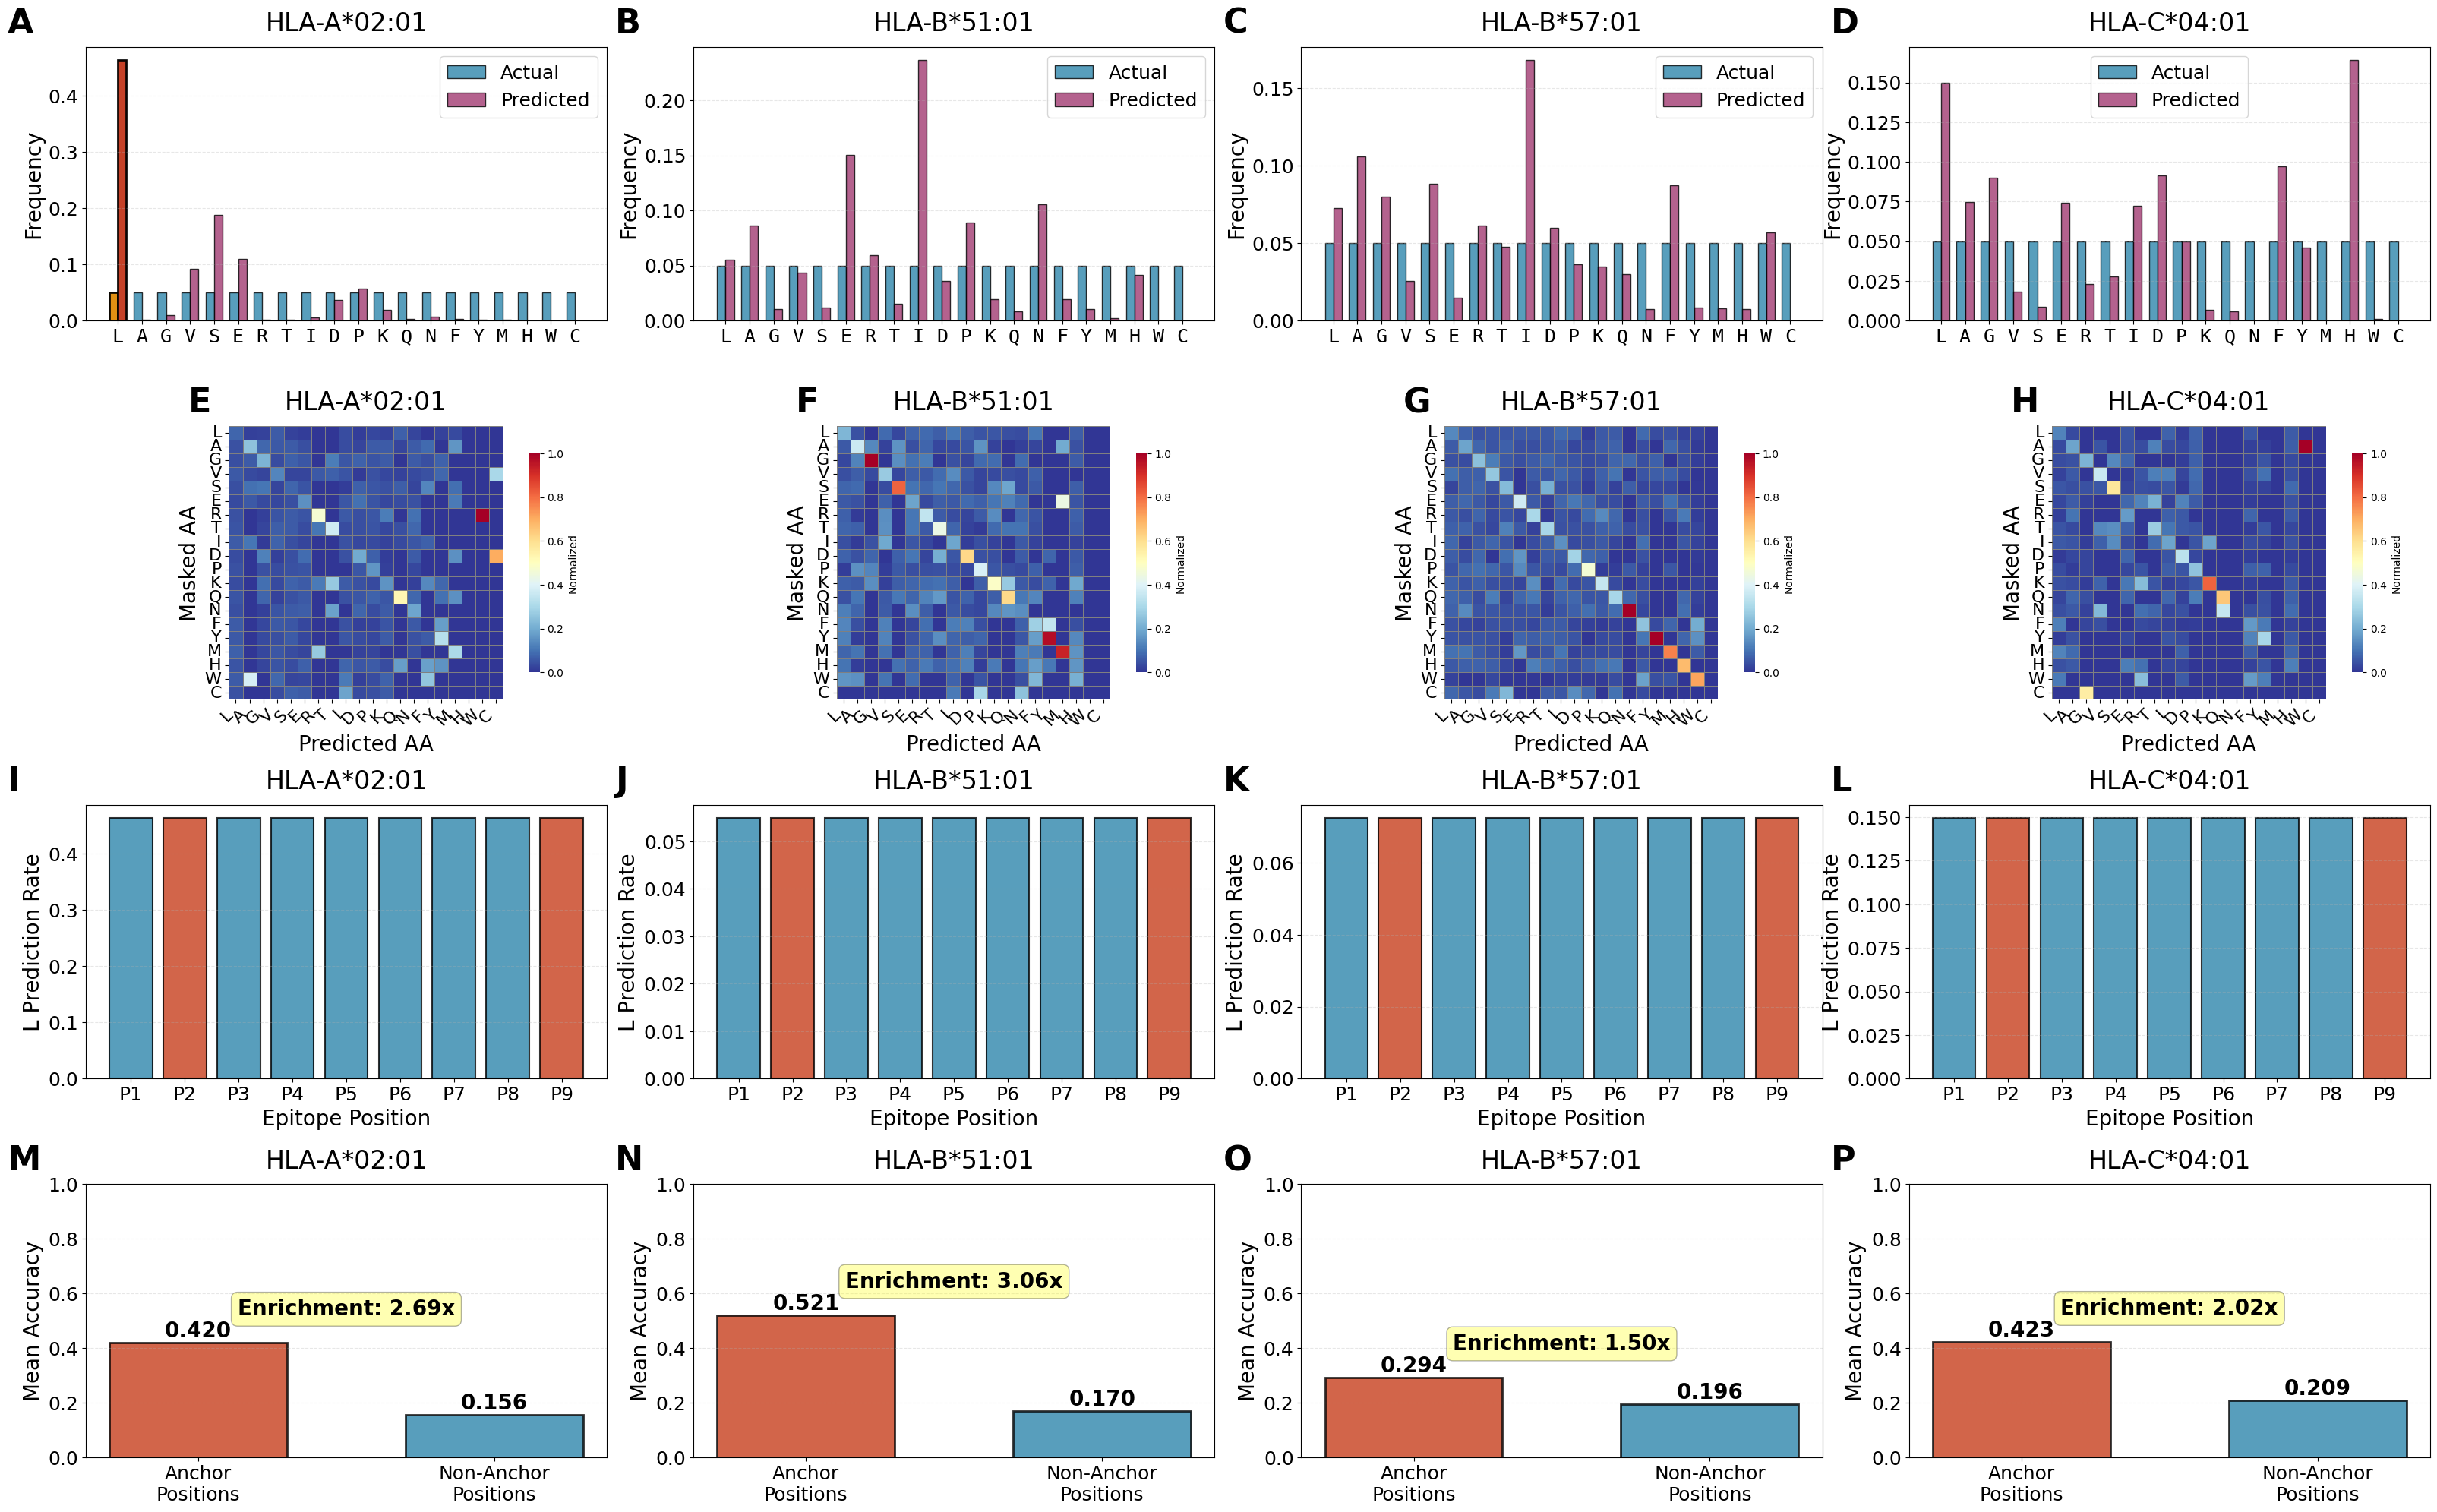

In [ ]:
fig = plt.figure(figsize=(32, 20))

allele_names = list(allele_analysis_data.keys())
anchor_positions = {
    'A0201': [2, 9],
    'B5101': [2, 9],
    'B5701': [2, 9],
    'C0401': [2, 9]
}

amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

for allele_idx, allele_name in enumerate(allele_names):
    data = allele_analysis_data[allele_name]
    best_model = data['best_model']
    conf_mat = data['confusion_matrix'].iloc[2:, 2:]
    hla_formatted = f"HLA-{allele_name[0]}*{allele_name[1:3]}:{allele_name[3:]}"
    
    ax1 = plt.subplot(4, len(allele_names), allele_idx + 1)
    
    actual_freq = conf_mat.sum(axis=1) / conf_mat.sum(axis=1).sum()
    predicted_freq = conf_mat.sum(axis=0) / conf_mat.sum(axis=0).sum()
    
    x_pos = np.arange(len(actual_freq))
    width = 0.35
    
    ax1.bar(x_pos - width/2, actual_freq, width, label='Actual', color='#2E86AB', alpha=0.8, edgecolor='black')
    ax1.bar(x_pos + width/2, predicted_freq, width, label='Predicted', color='#A23B72', alpha=0.8, edgecolor='black')
    
    if allele_name == 'A0201':
        l_idx = list(actual_freq.index).index('L')
        ax1.bar(l_idx - width/2, actual_freq.iloc[l_idx], width, color='#F18F01', alpha=0.9, edgecolor='black', linewidth=2)
        ax1.bar(l_idx + width/2, predicted_freq.iloc[l_idx], width, color='#C73E1D', alpha=0.9, edgecolor='black', linewidth=2)
    
    ax1.set_ylabel('Frequency', fontsize=20)
    ax1.set_title(f'{hla_formatted}', fontsize=24, pad=15)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(actual_freq.index, fontsize=16, family='monospace')
    ax1.tick_params(axis='both', labelsize=18)
    ax1.legend(fontsize=18)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.text(-0.15, 1.05, chr(65 + allele_idx), transform=ax1.transAxes, fontsize=32, fontweight='bold')
    
    ax2 = plt.subplot(4, len(allele_names), allele_idx + 1 + len(allele_names))
    
    freq_adjusted_conf = conf_mat.copy()
    for i in conf_mat.index:
        for j in conf_mat.columns:
            actual_freq_i = actual_freq[i] if i in actual_freq.index else 1e-10
            predicted_freq_j = predicted_freq[j] if j in predicted_freq.index else 1e-10
            freq_adjusted_conf.loc[i, j] = conf_mat.loc[i, j] / (actual_freq_i * predicted_freq_j + 1e-10)
    
    freq_adjusted_conf = freq_adjusted_conf / freq_adjusted_conf.max().max()
    
    sns.heatmap(freq_adjusted_conf, annot=False, cmap='RdYlBu_r', cbar=True,
                square=True, linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'Normalized', 'shrink': 0.8},
                ax=ax2, vmin=0, vmax=1, center=0.5)
    
    ax2.set_xlabel('Predicted AA', fontsize=20)
    ax2.set_ylabel('Masked AA', fontsize=20)
    ax2.set_title(f'{hla_formatted}', fontsize=24, pad=15)
    ax2.tick_params(axis='both', labelsize=16)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=16)
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=16)
    ax2.text(-0.15, 1.05, chr(65 + allele_idx + 4), transform=ax2.transAxes, fontsize=32, fontweight='bold')
    
    ax3 = plt.subplot(4, len(allele_names), allele_idx + 1 + 2*len(allele_names))
    
    positions = range(1, 10)
    anchor_pos = anchor_positions.get(allele_name, [2, 9])
    
    leucine_prediction_by_pos = {}
    for pos in positions:
        pos_data = []
        for i in conf_mat.index:
            if 'L' in conf_mat.columns:
                pos_data.append(conf_mat.loc[i, 'L'])
        leucine_prediction_by_pos[pos] = np.mean(pos_data) if pos_data else 0
    
    colors = ['#C73E1D' if p in anchor_pos else '#2E86AB' for p in positions]
    
    ax3.bar(range(len(positions)), [leucine_prediction_by_pos.get(p, 0) for p in positions],
            color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax3.set_xlabel('Epitope Position', fontsize=20)
    ax3.set_ylabel('L Prediction Rate', fontsize=20)
    ax3.set_title(f'{hla_formatted}', fontsize=24, pad=15)
    ax3.set_xticks(range(len(positions)))
    ax3.set_xticklabels([f'P{p}' for p in positions], fontsize=18)
    ax3.tick_params(axis='both', labelsize=18)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.text(-0.15, 1.05, chr(65 + allele_idx + 8), transform=ax3.transAxes, fontsize=32, fontweight='bold')
    
    ax4 = plt.subplot(4, len(allele_names), allele_idx + 1 + 3*len(allele_names))
    
    pos_acc = data['position_accuracy_all'][best_model]
    anchor_acc = np.mean([pos_acc[p] for p in anchor_pos if p in pos_acc.index])
    non_anchor_acc = np.mean([pos_acc[p] for p in positions if p not in anchor_pos and p in pos_acc.index])
    enrichment = anchor_acc / (non_anchor_acc + 1e-10)
    
    ax4.bar([0, 1], [anchor_acc, non_anchor_acc], color=['#C73E1D', '#2E86AB'],
            alpha=0.8, edgecolor='black', linewidth=2, width=0.6)
    
    ax4.text(0, anchor_acc + 0.02, f'{anchor_acc:.3f}', ha='center', fontsize=20, fontweight='bold')
    ax4.text(1, non_anchor_acc + 0.02, f'{non_anchor_acc:.3f}', ha='center', fontsize=20, fontweight='bold')
    ax4.text(0.5, max(anchor_acc, non_anchor_acc) + 0.1, f'Enrichment: {enrichment:.2f}x',
             ha='center', fontsize=20, fontweight='bold', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    ax4.set_ylabel('Mean Accuracy', fontsize=20)
    ax4.set_title(f'{hla_formatted}', fontsize=24, pad=15)
    ax4.set_xticks([0, 1])
    ax4.set_xticklabels(['Anchor\nPositions', 'Non-Anchor\nPositions'], fontsize=18)
    ax4.set_ylim(0, 1)
    ax4.tick_params(axis='both', labelsize=18)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.text(-0.15, 1.05, chr(65 + allele_idx + 12), transform=ax4.transAxes, fontsize=32, fontweight='bold')

plt.tight_layout()
# plt.savefig('hla_specificity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
allele_analysis_data['A0201']['models_data']['_epitope_FT_15_0.001_1e-06_AUG_1_A0201_1']

TypeError: list indices must be integers or slices, not str

In [ ]:
ff

NameError: name 'ff' is not defined

In [ ]:
allele_analysis_data['A0201']['models_data']['_epitope_FT_15_0.001_1e-06_AUG_1_A0201_1'] #[['epitope','position']] #.to_csv('/global/scratch/users/sergiomar10/ESMCBA/A0201_eval_epitopes_confusion_matrix.csv', index= None)
 #['epitope'].nunique()

,epitope,position,original_id,predicted_id,predicted_prob,token_nll
0,SLYGASPGL,0,0,0,0.999891,0.000109
1,SLYGASPGL,1,8,8,0.291456,1.232867
2,SLYGASPGL,2,4,4,0.375175,0.980364
3,SLYGASPGL,6,8,7,0.207015,2.500466
4,FQNPQTHVIEN,4,14,9,0.240715,2.477989
...,...,...,...,...,...,...
10884,APGAPGPKAA,10,5,4,0.217816,2.582054
10885,SILSNIHEV,2,12,4,0.469221,2.839782
10886,SILSNIHEV,4,8,9,0.303724,2.014855
10887,SILSNIHEV,10,2,2,0.999959,0.000041


In [ ]:
allele_analysis_data['B5101']['models_data']['_epitope_FT_25_0.001_1e-06_AUG_3_B5101_2']['epitope'].nunique()

1307

In [ ]:
allele_analysis_data['B5701']['models_data']['_epitope_FT_25_0.001_5e-05_AUG_4_B5701_1']['epitope'].nunique()

1858

In [ ]:
data2x = allele_analysis_data['C0401']['models_data']['_epitope_FT_15_0.001_1e-05_AUG_3_C0401_2'] #['epitope'].str.contains('C') #['epitope'].nunique()

In [ ]:
data2x[data2x['epitope'].str.contains('C')]

,epitope,position,original_id,predicted_id,predicted_prob,token_nll
36,EACTGP,4,11,4,0.221624,2.890801
37,EACTGP,6,14,18,0.718048,6.715076
88,CPREWVSL,2,14,18,0.290085,3.027705
89,CPREWVSL,8,4,4,0.327736,1.115547
90,CPREWVSL,9,2,2,0.999985,0.000015
117,SSGCPAG,0,0,0,0.999625,0.000375
118,SSGCPAG,7,6,4,0.681139,3.850236
397,RRRWCGLGL,2,10,18,0.331471,3.491850
398,RRRWCGLGL,3,10,18,0.156803,3.117117
399,RRRWCGLGL,5,23,6,0.246866,7.903481


In [ ]:
vocab

{'<cls>': 0,
 '<pad>': 1,
 '<eos>': 2,
 '<unk>': 3,
 'L': 4,
 'A': 5,
 'G': 6,
 'V': 7,
 'S': 8,
 'E': 9,
 'R': 10,
 'T': 11,
 'I': 12,
 'D': 13,
 'P': 14,
 'K': 15,
 'Q': 16,
 'N': 17,
 'F': 18,
 'Y': 19,
 'M': 20,
 'H': 21,
 'W': 22,
 'C': 23,
 'X': 24,
 'B': 25,
 'U': 26,
 'Z': 27,
 'O': 28,
 '.': 29,
 '-': 30,
 '<null_1>': 31,
 '<mask>': 32}

In [ ]:
directory = '/global/scratch/users/sergiomar10/models/ESMC_Pretrain/'
summary_df['model_path'] = directory + 'HLA' + summary_df['HLA'] + '/' + summary_df['File'].str.replace('_per_token_metrics.csv','.pt')
# /global/scratch/users/sergiomar10/models/ESMC_Pretrain/HLAHLAB2703/ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB2703_2.pt

In [ ]:
summary_df = summary_df[summary_df['HLA'].apply(len) > 4]

In [ ]:
summary_df['Encoding'] = summary_df['File'].str.split('_').str[1]

/tmp/ipykernel_143320/2614477926.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])  # leave space for the global x‑label


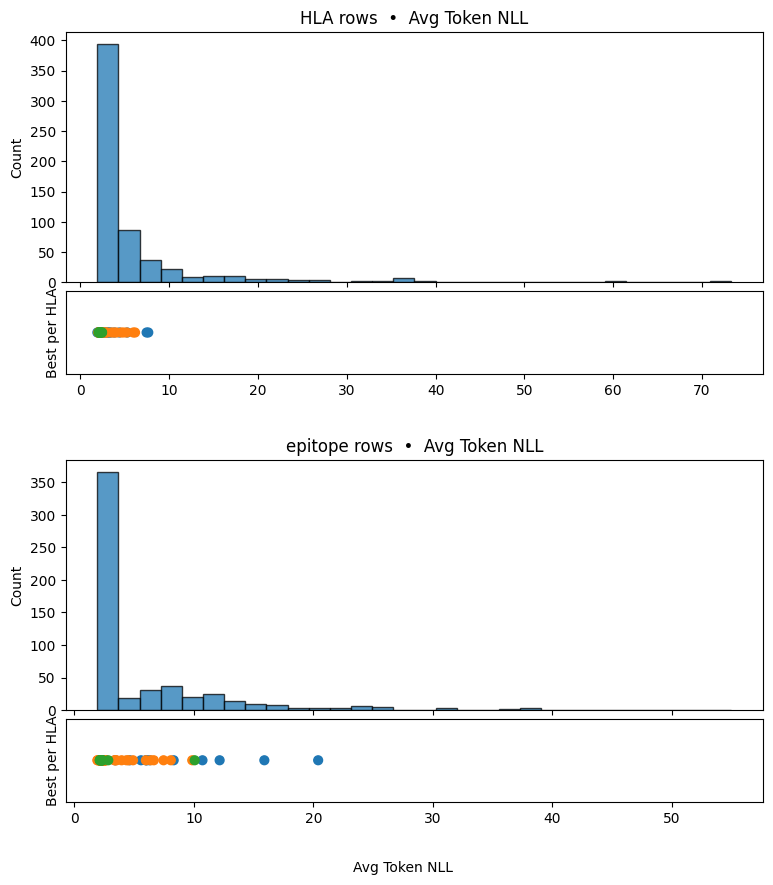

In [ ]:
import matplotlib.gridspec as gridspec

thresh = 200                           # keep everything with Avg_Token_NLL < 200
enc_levels = ['HLA', 'epitope']        # order to plot

fig = plt.figure(figsize=(9, 10))
outer = gridspec.GridSpec(2, 1, hspace=0.25)   # two big rows (top / bottom)

for i, enc in enumerate(enc_levels):
    # -------------------------------------------------------------
    # 1. Filter by encoding and quality threshold
    # -------------------------------------------------------------
    enc_df = summary_df.loc[
        (summary_df['Encoding'] == enc) &
        (summary_df['Avg_Token_NLL'] < thresh)
    ]

    # “best” (lowest NLL) line per HLA, even for epitope‑encoded rows
    best = (enc_df.sort_values('Avg_Token_NLL')
                    .groupby('HLA', as_index=False)
                    .first())

    # -------------------------------------------------------------
    # 2. Build a nested 2×1 grid: hist on top, lollipop underneath
    # -------------------------------------------------------------
    gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[i],
        height_ratios=[3, 1], hspace=0.05
    )
    ax_hist  = plt.Subplot(fig, gs[0])
    ax_lolli = plt.Subplot(fig, gs[1], sharex=ax_hist)
    fig.add_subplot(ax_hist);  fig.add_subplot(ax_lolli)

    # Histogram
    ax_hist.hist(enc_df['Avg_Token_NLL'], bins=30,
                 alpha=0.75, edgecolor='black')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f"{enc} rows  •  Avg Token NLL")

    # Lollipop stems
    # ax_lolli.stem(best['Avg_Token_NLL'].values,
    #               np.zeros(len(best)),
    #               linefmt='-', markerfmt='o', basefmt=' ')
    ax_lolli.set_yticks([])
    ax_lolli.set_ylabel('Best per HLA')

    # Colour markers by HLA class (optional)
    family_colors = best['HLA'].str[0].map({'A':'tab:blue',
                                            'B':'tab:orange',
                                            'C':'tab:green'})
    ax_lolli.scatter(best['Avg_Token_NLL'], np.zeros(len(best)),
                     c=family_colors, s=40, zorder=3)

# Shared x‑label across both blocks
fig.text(0.5, 0.04, 'Avg Token NLL', ha='center')
plt.tight_layout(rect=[0, 0.04, 1, 1])  # leave space for the global x‑label
plt.show()


In [ ]:
summary_df.to_csv('summary_of_pretrained_models.csv', index=False)

In [ ]:
summary_df['Model'] = summary_df['HLA']  + '+' + summary_df['Encoding']

195


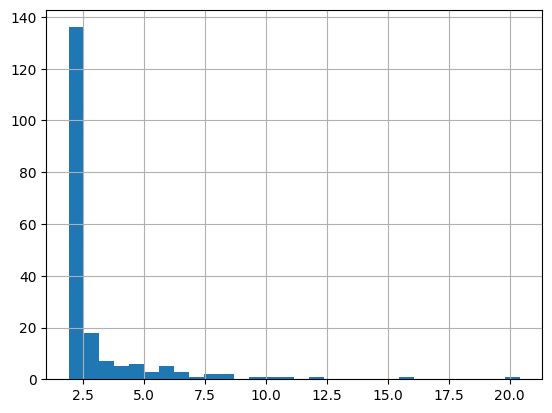

In [ ]:
set_for_ba_set = summary_df.drop_duplicates('Model')
set_for_ba_set = set_for_ba_set.reset_index(drop=True)
set_for_ba_set[set_for_ba_set['Avg_Token_NLL'] < 200]['Avg_Token_NLL'].hist(bins=30)
print(len(set_for_ba_set))

In [ ]:
set_for_ba_set['Avg_Token_NLL'] #.groupby('Encoding')['HLA'].size()

0       1.901193
1       1.924789
2       1.965931
3       2.026100
4       2.027073
         ...    
190    10.723267
191    12.159410
192    15.902370
193    20.406329
194          inf
Name: Avg_Token_NLL, Length: 195, dtype: float64

In [ ]:
fsafas

NameError: name 'fsafas' is not defined

In [ ]:
# Function to check if a file path exists
def check_path(path):
    return os.path.exists(path)

# Apply the check to the model_path column
set_for_ba_set['path_exists'] = set_for_ba_set['model_path'].apply(check_path)

# Identify non-existent paths
non_existent_paths = set_for_ba_set[~set_for_ba_set['path_exists']][['model_path']]

# Optionally, filter DataFrame to keep only rows with existing paths
set_for_ba_set = set_for_ba_set[set_for_ba_set['path_exists']]

# Drop the temporary 'path_exists' column if not needed
set_for_ba_set = set_for_ba_set.drop(columns=['path_exists'])

In [ ]:
set_for_ba_set[set_for_ba_set['HLA'] == 'A0201']

,File,HLA,Avg_Token_NLL,model_path,Encoding,Model
33,ESMMASK_epitope_FT_15_0.001_1e-05_AUG_3_A0201_...,A0201,2.131671,/global/scratch/users/sergiomar10/models/ESMC_...,epitope,A0201+epitope
54,ESMMASK_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_1_p...,A0201,2.176863,/global/scratch/users/sergiomar10/models/ESMC_...,HLA,A0201+HLA


In [ ]:
# set_for_ba_set.to_csv('file_paths.csv', index=False)

### Create SLURM files

In [ ]:
################################################
# 6. Define a simple FASTA parser
################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        # Append the last sequence if present
        if seq:
            sequences.append((header, seq))
    return sequences


############################################
# 7. Load and filter the data
############################################
train_fasta = "/global/scratch/users/sergiomar10/jupyter_notebooks/hla_protein_sequences.fasta"
all_data = parse_fasta(train_fasta)

filtered_data = []
for header, sequence in all_data:
    if sequence[0] != 'M':
        continue
    if len(sequence) < 50:
        continue
    if 'X' in sequence:
        continue

    header = header.split('|')[1][:7].replace('*','').replace(':','')

    filtered_data.append(('HLA' + header))
    

In [ ]:
import os

#########################################################
# FASTA Parser
#########################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        if seq:
            sequences.append((header, seq))
    return sequences

#########################################################
# Load HLA Sequences
#########################################################
fasta_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/hla_sequences.fasta"
hla_data = parse_fasta(fasta_path)

hla_sequences = [
    header for header, seq in hla_data
]


In [ ]:
hla_sequences = [x.replace('*','').replace(':','') for x in hla_sequences]

In [ ]:
HLAs = hla_sequences

In [ ]:
import itertools
import os
import glob

script_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/models/ESM_Unsupervised/ESM-C_ALLHLAs.py'
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/ESMC_pretrain3'
os.makedirs(sh_file_dir, exist_ok=True)

trials = [1, 2]
encoding = ['epitope', 'HLA']
blocks_unfrozen = [15, 20, 25]
last_block_lr = [1e-3, 1e-4, 1e-5]
regression_block_lr = [1e-6, 5e-5, 1e-5]
num_augmentations = [1, 3, 4]
                    
for trial_n, encode, num_block, lr_base, lr_reg, HLA, augs  in itertools.product(trials, encoding, blocks_unfrozen, last_block_lr, regression_block_lr, HLAs, num_augmentations):
    
    file_name = f'ESMMASK_{encode}_FT_{num_block}_{lr_base}_{lr_reg}_AUG_{augs}_{HLA}_{trial_n}'

    sh_filename = f'{file_name}.sh'
    sh_filepath = os.path.join(sh_file_dir, sh_filename)
    
    # Construct the command to run the script with the current parameters
    cmd = f'python3 {script_path} --name_of_model {file_name} --encoding {encode} --blocks_unfrozen {num_block} --base_block_lr {lr_base} --regression_block_lr {lr_reg} --HLA HLA{HLA} --num_augmentations {augs}'

    with open(sh_filepath, 'w') as sh_file:
        sh_file.write('#!/bin/bash\n')
        sh_file.write('#SBATCH --account=co_nilah\n')
        sh_file.write('#SBATCH --partition=savio2_1080ti\n')
        sh_file.write('#SBATCH --qos=savio_lowprio\n')
        sh_file.write('#SBATCH --cpus-per-task=4\n')
        sh_file.write('#SBATCH --gres=gpu:1\n')
        sh_file.write('#SBATCH --requeue\n')
        sh_file.write('#SBATCH --time=03:00:00\n')
        sh_file.write(f'#SBATCH --job-name={file_name}\n')
        sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.out\n')
        sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.err\n')
        sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
        sh_file.write('\n')
        sh_file.write('conda activate ESM_cambrian\n')
        sh_file.write('\n')

        sh_file.write(cmd + '\n')
        
    # Make the shell script executable
    os.chmod(sh_filepath, 0o755)
    
    print(f'Created shell script: {file_name}')
    # break


Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0202_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_4_A0203_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_A0204_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_A0204_1
Created shell script